In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster         import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition   import PCA
from sklearn.manifold        import TSNE
from sklearn.neighbors       import NearestNeighbors
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics         import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics         import silhouette_samples

from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.stats           as stats
import joblib

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3

print("all imports done")

all imports done


In [ ]:
df_raw = pd.read_csv('Wholesale customers data.csv')

print(f"shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(df_raw.info())
display(df_raw.head())
display(df_raw.describe().round(1))
print("missing values:")
print(df_raw.isnull().sum())
print(f"total missing: {df_raw.isnull().sum().sum()}")

shape: 440 rows x 8 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
mean,1.3,2.5,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,0.5,0.8,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,1.0,1.0,3.0,55.0,3.0,25.0,3.0,3.0
25%,1.0,2.0,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,1.0,3.0,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,2.0,3.0,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,2.0,3.0,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


missing values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
total missing: 0


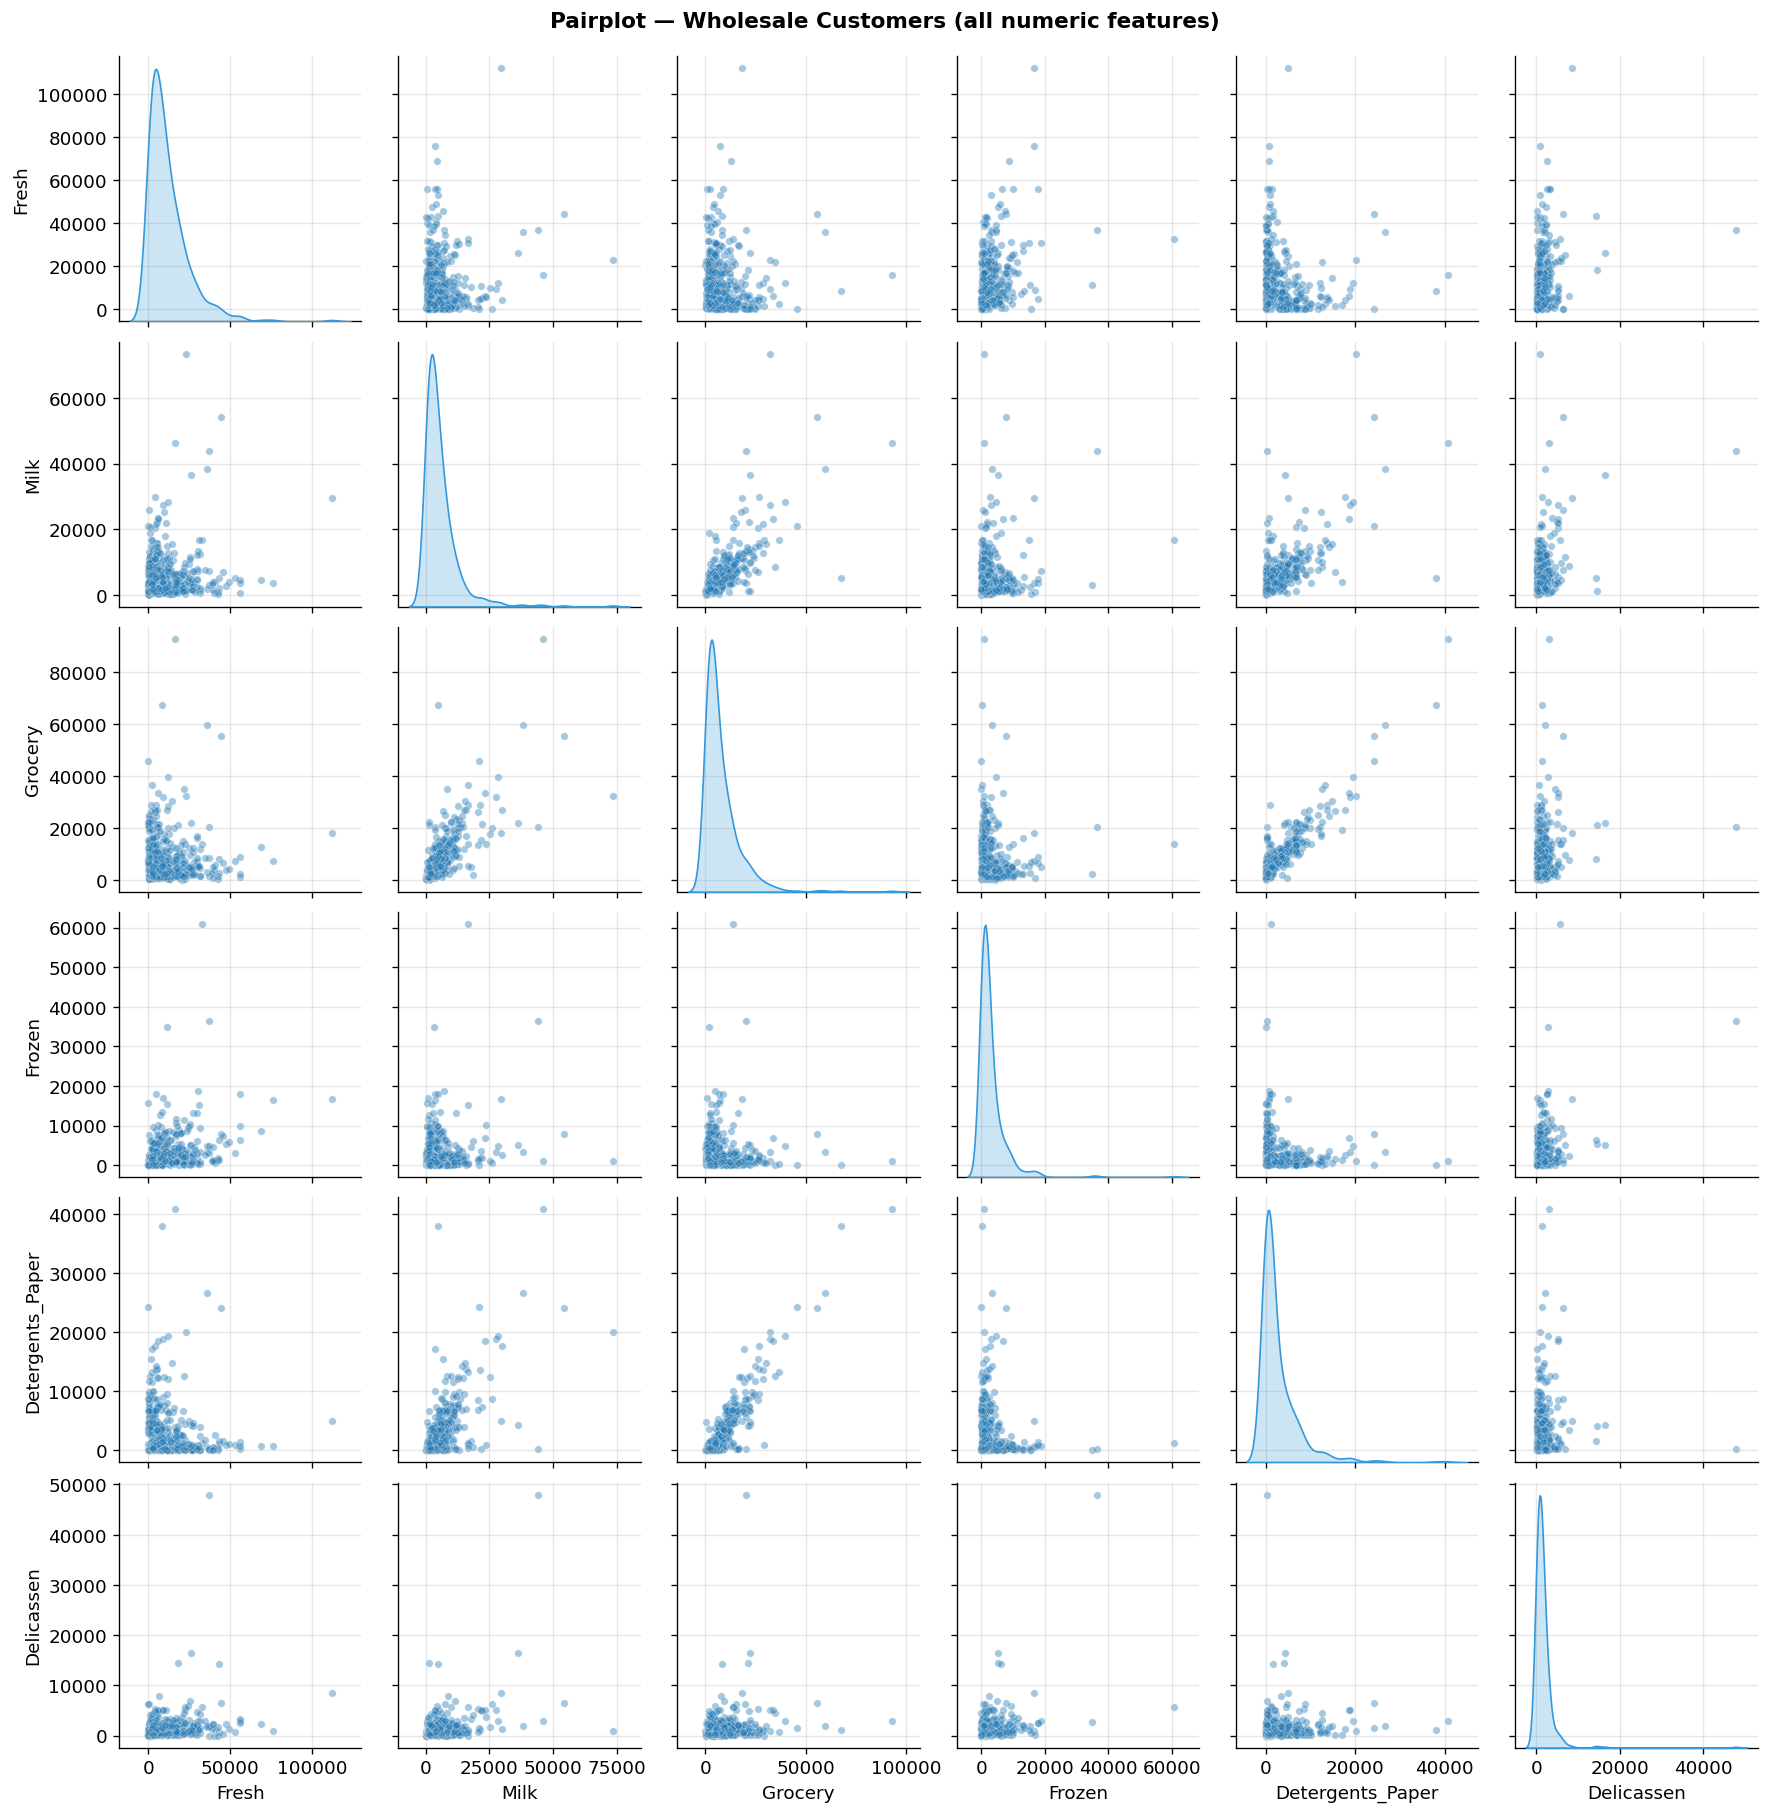

clearest visual groupings: Fresh vs Grocery, Detergents_Paper vs Grocery


In [ ]:
numeric_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

g = sns.pairplot(df_raw[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20},
                 diag_kws={'color': '#3498db'})
g.fig.suptitle('Pairplot — Wholesale Customers (all numeric features)',
               fontweight='bold', y=1.01, fontsize=13)
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("clearest visual groupings: Fresh vs Grocery, Detergents_Paper vs Grocery")

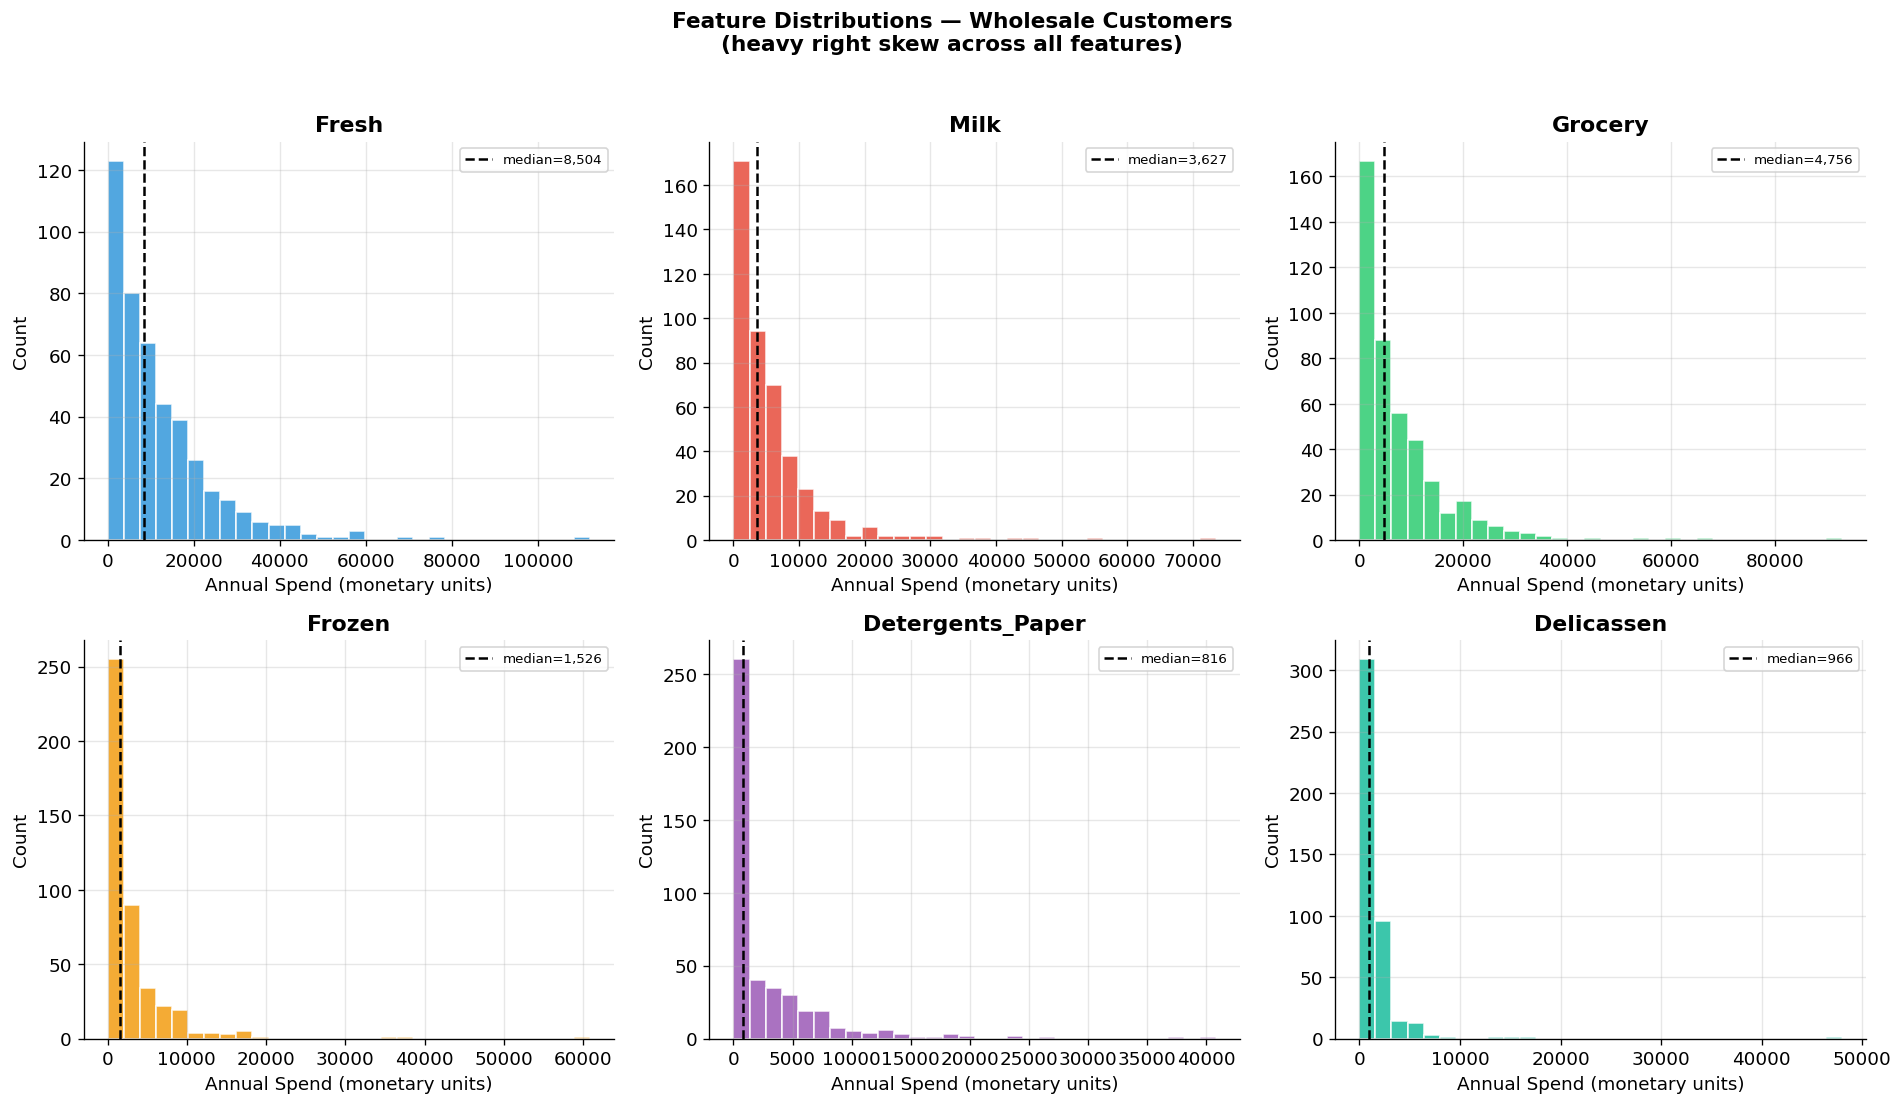

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colours = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for ax, col, colour in zip(axes, numeric_cols, colours):
    ax.hist(df_raw[col], bins=30, color=colour, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Annual Spend (monetary units)')
    ax.set_ylabel('Count')
    ax.axvline(df_raw[col].median(), color='black', linestyle='--', lw=1.5,
               label=f'median={df_raw[col].median():,.0f}')
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions — Wholesale Customers\n(heavy right skew across all features)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

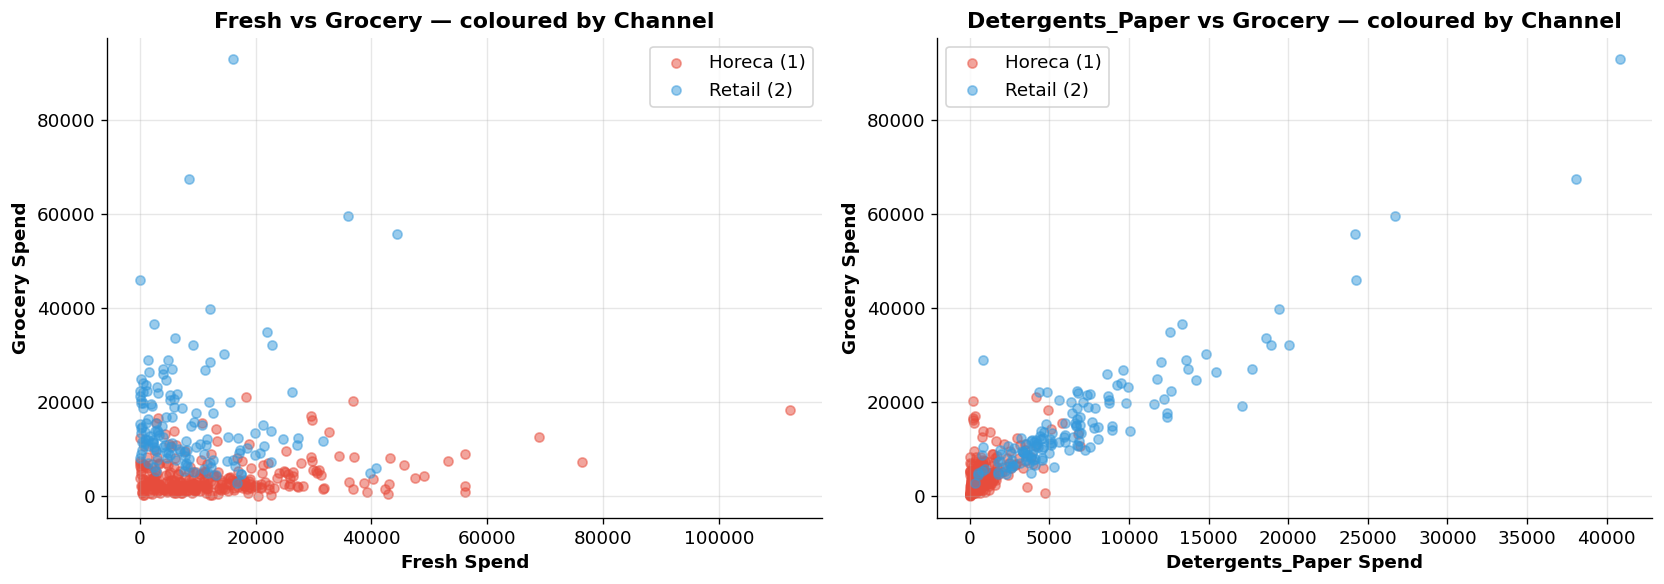

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

channel_colours = {1: '#e74c3c', 2: '#3498db'}
channel_labels  = {1: 'Horeca (1)', 2: 'Retail (2)'}

for ch in [1, 2]:
    mask = df_raw['Channel'] == ch
    ax1.scatter(df_raw.loc[mask, 'Fresh'], df_raw.loc[mask, 'Grocery'],
                c=channel_colours[ch], label=channel_labels[ch], alpha=0.5, s=30)
    ax2.scatter(df_raw.loc[mask, 'Detergents_Paper'], df_raw.loc[mask, 'Grocery'],
                c=channel_colours[ch], label=channel_labels[ch], alpha=0.5, s=30)

ax1.set_xlabel('Fresh Spend', fontweight='bold'); ax1.set_ylabel('Grocery Spend', fontweight='bold')
ax1.set_title('Fresh vs Grocery — coloured by Channel', fontweight='bold'); ax1.legend()

ax2.set_xlabel('Detergents_Paper Spend', fontweight='bold'); ax2.set_ylabel('Grocery Spend', fontweight='bold')
ax2.set_title('Detergents_Paper vs Grocery — coloured by Channel', fontweight='bold'); ax2.legend()

plt.tight_layout()
plt.savefig('scatter_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

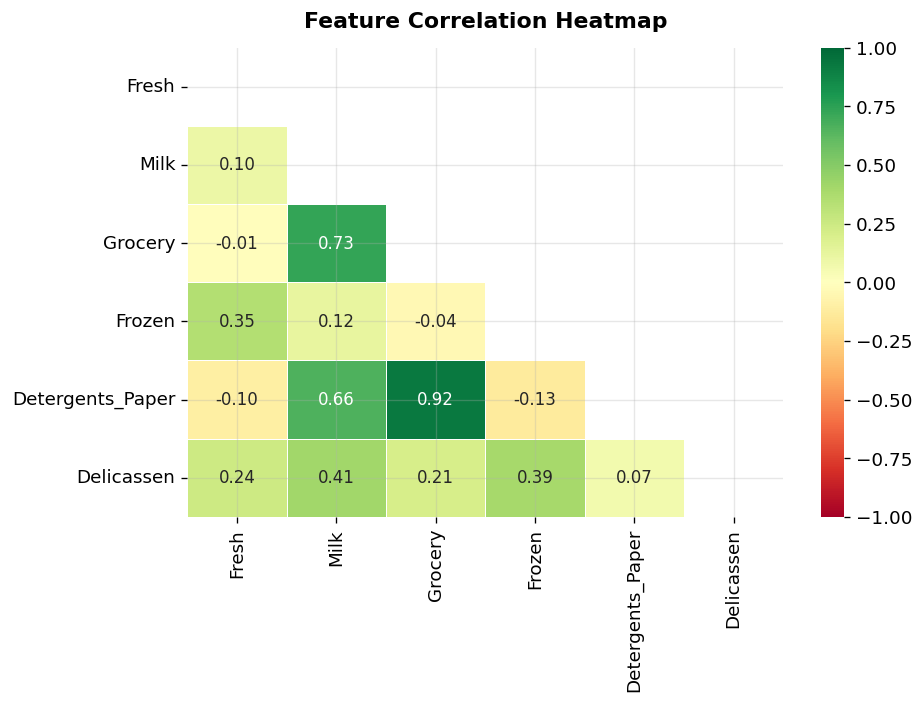

strongest correlations:
Grocery  Detergents_Paper    0.924641
Milk     Grocery             0.728335
         Detergents_Paper    0.661816
         Delicassen          0.406368
Frozen   Delicassen          0.390947


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_raw[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 10})
ax.set_title('Feature Correlation Heatmap', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("strongest correlations:")
corr_pairs = corr.unstack().drop_duplicates().sort_values(ascending=False)
print(corr_pairs[corr_pairs < 1.0].head(5).to_string())

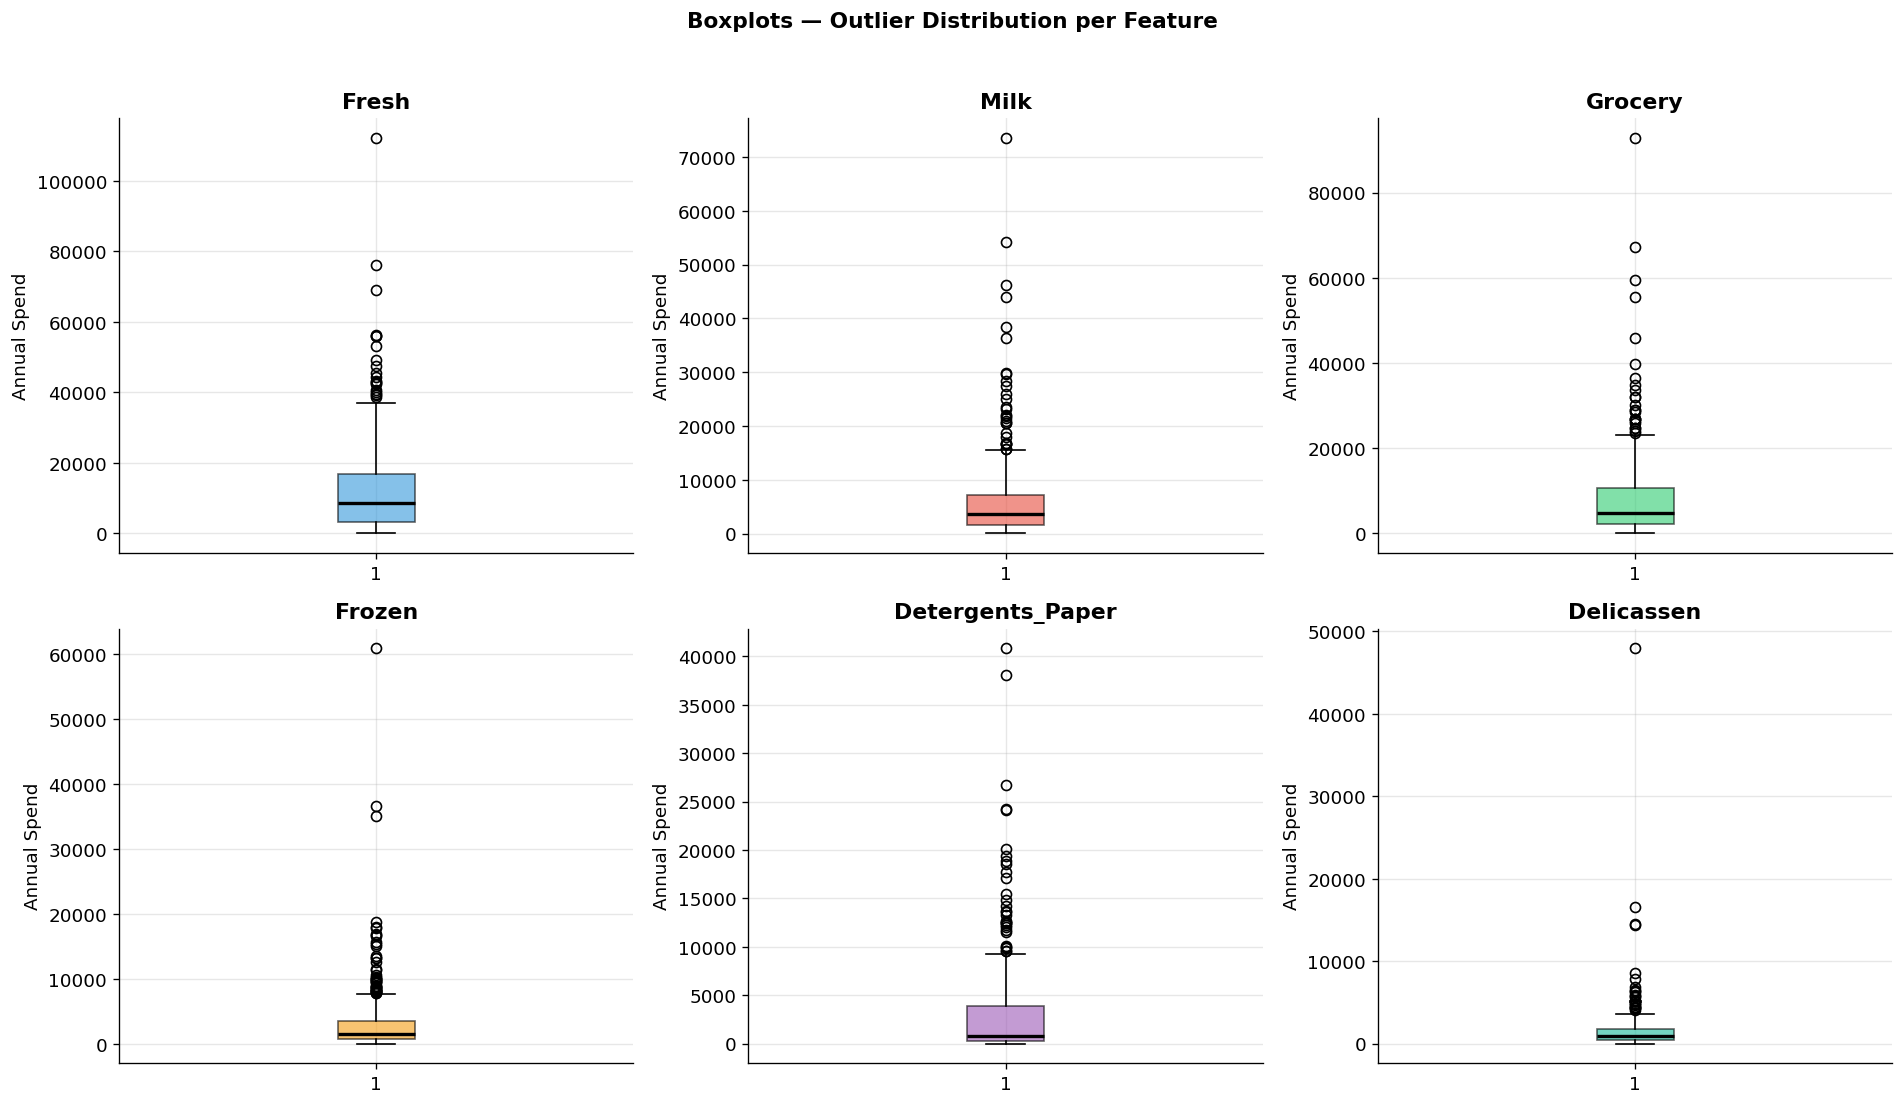

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col, colour in zip(axes, numeric_cols, colours):
    ax.boxplot(df_raw[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=colour, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Annual Spend')

fig.suptitle('Boxplots — Outlier Distribution per Feature', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df = df_raw.drop(columns=['Channel', 'Region']).copy()

X2 = df[['Grocery', 'Detergents_Paper']].copy()
X3 = df[['Fresh', 'Grocery', 'Detergents_Paper']].copy()

print(f"df shape after dropping Channel/Region: {df.shape}")
print(f"X2 features: {X2.columns.tolist()}")
print(f"X3 features: {X3.columns.tolist()}")
print(f"missing values: {df.isnull().sum().sum()}")

df shape after dropping Channel/Region: (440, 6)
X2 features: ['Grocery', 'Detergents_Paper']
X3 features: ['Fresh', 'Grocery', 'Detergents_Paper']
missing values: 0


the feature set i chose for X2 was Grocery + Detergents_Paper because when i looked at the pairplot those two showed the clearest separation — one group buys a lot of both, another barely touches detergents. for X3 i added Fresh because that's the opposite signal — Horeca customers spend heavily on fresh produce and almost nothing on packaged goods.

In [ ]:
scaler2 = StandardScaler()
scaler3 = StandardScaler()

X2_scaled = scaler2.fit_transform(X2)
X3_scaled = scaler3.fit_transform(X3)

print("before scaling:")
print(f"{'Feature':<20} {'Mean':>12} {'Std':>12}")
print("-" * 46)
for col in X2.columns:
    print(f"{col:<20} {X2[col].mean():>12.1f} {X2[col].std():>12.1f}")

print("\nafter scaling:")
print(f"{'Feature':<20} {'Mean':>12} {'Std':>12}")
print("-" * 46)
for i, col in enumerate(X2.columns):
    print(f"{col:<20} {X2_scaled[:, i].mean():>12.6f} {X2_scaled[:, i].std():>12.6f}")

print("\nmean ≈ 0 and std ≈ 1 confirmed")

before scaling:
Feature                      Mean          Std
----------------------------------------------
Grocery                    7951.3       9503.2
Detergents_Paper           2881.5       4767.9

after scaling:
Feature                      Mean          Std
----------------------------------------------
Grocery                 -0.000000     1.000000
Detergents_Paper         0.000000     1.000000

mean ≈ 0 and std ≈ 1 confirmed


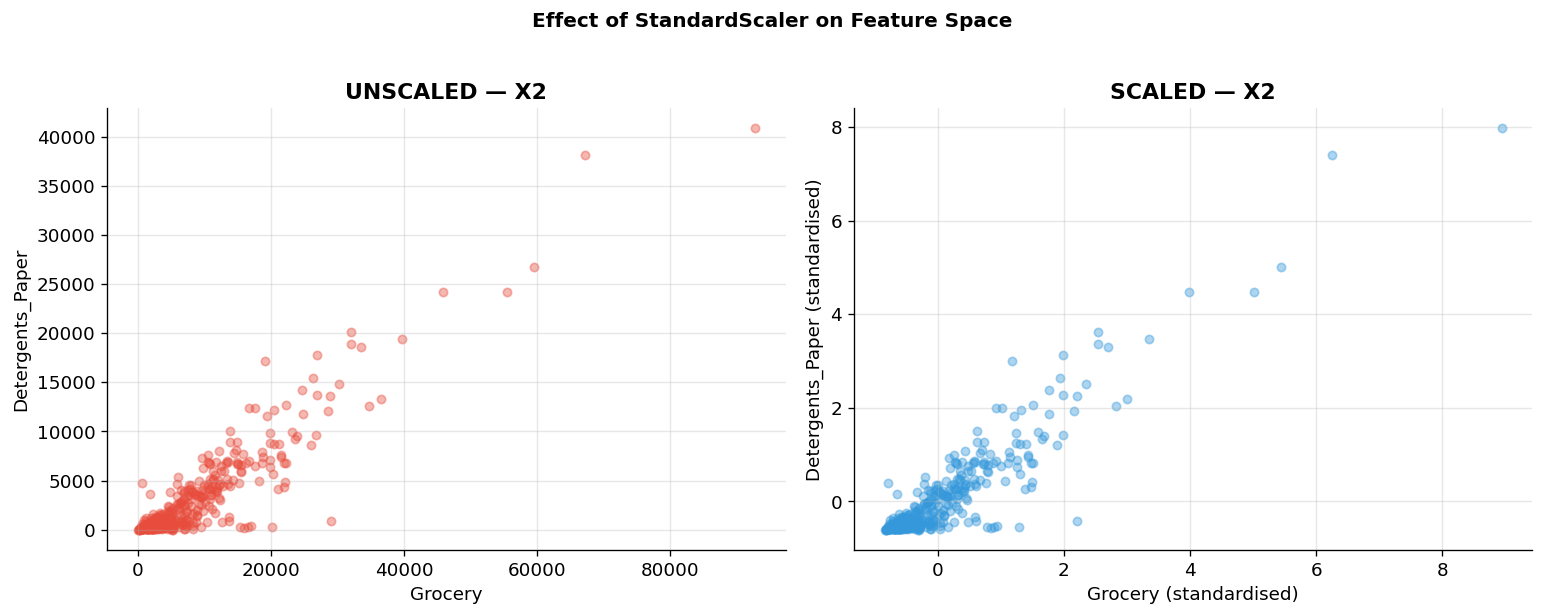

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(X2['Grocery'], X2['Detergents_Paper'], alpha=0.4, s=25, color='#e74c3c')
ax1.set_xlabel('Grocery'); ax1.set_ylabel('Detergents_Paper')
ax1.set_title('UNSCALED — X2', fontweight='bold')

ax2.scatter(X2_scaled[:, 0], X2_scaled[:, 1], alpha=0.4, s=25, color='#3498db')
ax2.set_xlabel('Grocery (standardised)'); ax2.set_ylabel('Detergents_Paper (standardised)')
ax2.set_title('SCALED — X2', fontweight='bold')

fig.suptitle('Effect of StandardScaler on Feature Space', fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### why does K-Means fail on unscaled data?

K-Means calculates euclidean distance to assign every point to its nearest centroid. if Grocery ranges up to 92,000 and Detergents_Paper up to 40,000, then Grocery automatically dominates every distance calculation just because its numbers are bigger. a difference of 1000 in Grocery counts the same as 1000 in Detergents_Paper even though they're on totally different scales.

after standardising both features have mean=0 and std=1 so they contribute equally. the clusters actually reflect spending pattern differences rather than just which feature happened to have a bigger range.

In [ ]:
def evaluate_clustering(X, labels, model_name, verbose=True):
    """
    compute silhouette, davies-bouldin, and calinski-harabasz scores.
    handles DBSCAN noise points (label=-1) automatically.
    """
    unique_labels  = set(labels)
    n_clusters     = len(unique_labels - {-1})
    n_noise        = list(labels).count(-1)
    non_noise_mask = labels != -1

    if n_clusters < 2:
        if verbose:
            print(f"  {model_name}: only {n_clusters} cluster(s) found — cannot compute metrics")
        return {'Model': model_name, 'Silhouette': np.nan, 'DBI': np.nan,
                'CHI': np.nan, 'N_Clusters': n_clusters, 'N_Noise': n_noise}

    X_eval = X[non_noise_mask] if n_noise > 0 else X
    l_eval = labels[non_noise_mask] if n_noise > 0 else labels

    sil = silhouette_score(X_eval, l_eval)
    dbi = davies_bouldin_score(X_eval, l_eval)
    chi = calinski_harabasz_score(X_eval, l_eval)

    if verbose:
        print(f"\n{'='*55}")
        print(f"  {model_name.upper()}")
        print(f"{'='*55}")
        print(f"  clusters found : {n_clusters}")
        print(f"  noise points   : {n_noise}")
        print(f"  silhouette     : {sil:.4f}  (higher = better)")
        print(f"  DBI            : {dbi:.4f}  (lower = better)")
        print(f"  CHI            : {chi:.1f}  (higher = better)")

    return {'Model': model_name, 'Silhouette': round(sil, 4),
            'DBI': round(dbi, 4), 'CHI': round(chi, 1),
            'N_Clusters': n_clusters, 'N_Noise': n_noise}


def plot_clusters(X_2d, labels, model_name, centroids=None, ax=None, feature_names=None):
    """
    scatter plot coloured by cluster assignment.
    noise points (label=-1) plotted in grey. optionally overlays centroid markers.
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))

    unique_labels = sorted(set(labels))
    palette       = sns.color_palette('tab10', n_colors=max(len(unique_labels), 2))

    for i, label in enumerate(unique_labels):
        mask   = labels == label
        colour = 'lightgrey' if label == -1 else palette[i % len(palette)]
        name   = 'noise' if label == -1 else f'cluster {label}'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[colour], s=30, alpha=0.65, label=name, edgecolors='none')

    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1],
                   marker='*', s=280, c='black', zorder=5, label='centroids')

    fn = feature_names if feature_names else ['Feature 1', 'Feature 2']
    ax.set_xlabel(fn[0], fontweight='bold')
    ax.set_ylabel(fn[1], fontweight='bold')
    ax.set_title(model_name, fontweight='bold')
    ax.legend(fontsize=8, markerscale=1.2)

    if standalone:
        plt.tight_layout()
        plt.show()

print("evaluate_clustering() and plot_clusters() ready")

evaluate_clustering() and plot_clusters() ready


In [ ]:
km5 = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
km5.fit(X2_scaled)

labels_km5       = km5.labels_
centroids_scaled = km5.cluster_centers_
centroids_orig   = scaler2.inverse_transform(centroids_scaled)

baseline_results = evaluate_clustering(X2_scaled, labels_km5, 'K-Means (K=5)')
print(f"inertia (WCSS): {km5.inertia_:.2f}")


  K-MEANS (K=5)
  clusters found : 5
  noise points   : 0
  silhouette     : 0.5877  (higher = better)
  DBI            : 0.6604  (lower = better)
  CHI            : 984.0  (higher = better)
inertia (WCSS): 87.58


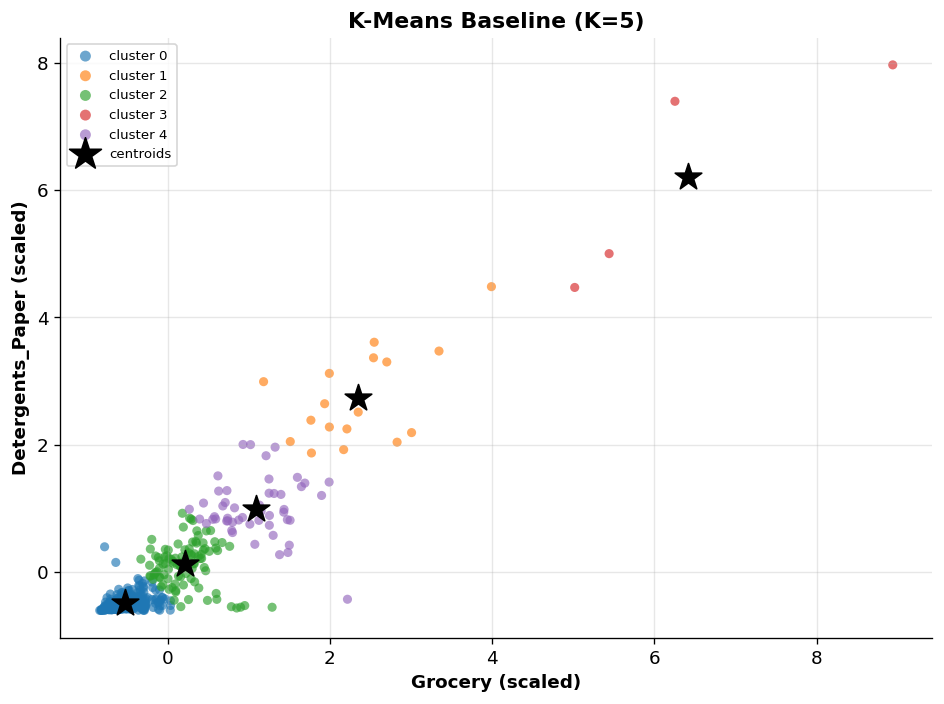

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_clusters(X2_scaled, labels_km5, 'K-Means Baseline (K=5)',
              centroids=centroids_scaled, ax=ax,
              feature_names=['Grocery (scaled)', 'Detergents_Paper (scaled)'])
plt.tight_layout()
plt.savefig('kmeans_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df['Cluster_KM5'] = labels_km5

print("centroid positions in original units:")
centroid_df = pd.DataFrame(centroids_orig, columns=X2.columns)
centroid_df.index.name = 'Cluster'
print(centroid_df.round(0).to_string())

print("\ncluster profile — mean of all features:")
profile_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
profile = df.groupby('Cluster_KM5')[profile_cols].mean().round(0)
display(profile)

print("\ncluster sizes:")
print(df['Cluster_KM5'].value_counts().sort_index().to_string())

centroid positions in original units:
         Grocery  Detergents_Paper
Cluster                           
0         2968.0             533.0
1        30190.0           15899.0
2        10004.0            3439.0
3        68812.0           32450.0
4        18228.0            7609.0

cluster profile — mean of all features:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster_KM5,,,,,,
0,12995.0,2755.0,2968.0,3450.0,533.0,1073.0
1,7414.0,19776.0,30190.0,1922.0,15899.0,1987.0
2,11570.0,7369.0,10004.0,2891.0,3439.0,2311.0
3,26272.0,35951.0,68812.0,3048.0,32450.0,3160.0
4,7925.0,11845.0,18228.0,1792.0,7609.0,2097.0



cluster sizes:
Cluster_KM5
0    269
1     17
2    100
3      4
4     50


In [ ]:
cluster_names = {}
for i, row in centroid_df.iterrows():
    g = row['Grocery']
    d = row['Detergents_Paper']
    if g > 20000 and d > 10000:
        cluster_names[i] = 'High-Volume Retailers'
    elif g > 15000:
        cluster_names[i] = 'Grocery-Heavy Buyers'
    elif d > 5000:
        cluster_names[i] = 'Detergent-Focused Stores'
    elif g < 5000 and d < 2000:
        cluster_names[i] = 'Low-Spend (Likely Horeca)'
    else:
        cluster_names[i] = 'Mid-Tier Mixed Buyers'

print("cluster name assignments based on centroid spend levels:")
for k, v in cluster_names.items():
    print(f"  cluster {k}: {v}")

cluster name assignments based on centroid spend levels:
  cluster 0: Low-Spend (Likely Horeca)
  cluster 1: High-Volume Retailers
  cluster 2: Mid-Tier Mixed Buyers
  cluster 3: High-Volume Retailers
  cluster 4: Grocery-Heavy Buyers


#### do these 5 clusters make business sense?

kind of. the two extreme clusters make clear sense — one group buys large amounts of both Grocery and Detergents_Paper which is obviously a large retail operation, another barely buys either which is probably small Horeca. those two are easy to name and explain.

the middle clusters are harder. two or three of them have pretty similar centroid values and it's not obvious what makes them genuinely different vs just being an artefact of forcing K=5. that's exactly why step 6 exists — i wasn't convinced K=5 was the right number going in.

In [ ]:
k_range  = range(2, 13)
inertias, sil_scores, dbi_scores, chi_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X2_scaled)
    labels = km.labels_
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X2_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X2_scaled, labels))
    chi_scores.append(calinski_harabasz_score(X2_scaled, labels))

k_results_df = pd.DataFrame({
    'K'         : list(k_range),
    'Inertia'   : inertias,
    'Silhouette': [round(s, 4) for s in sil_scores],
    'DBI'       : [round(d, 4) for d in dbi_scores],
    'CHI'       : [round(c, 1) for c in chi_scores]
})

print("K-Means metric sweep:")
print(k_results_df.to_string(index=False))

optimal_k_sil = k_results_df.loc[k_results_df['Silhouette'].idxmax(), 'K']
optimal_k_dbi = k_results_df.loc[k_results_df['DBI'].idxmin(), 'K']
optimal_k_chi = k_results_df.loc[k_results_df['CHI'].idxmax(), 'K']
print(f"\nbest K by silhouette : {optimal_k_sil}")
print(f"best K by DBI        : {optimal_k_dbi}")
print(f"best K by CHI        : {optimal_k_chi}")

K-Means metric sweep:
 K    Inertia  Silhouette    DBI    CHI
 2 389.385382      0.7306 0.6037  551.9
 3 199.057345      0.6793 0.5417  747.5
 4 118.027933      0.6279 0.5987  938.3
 5  87.579771      0.5877 0.6604  984.0
 6  68.270593      0.5926 0.6161 1032.0
 7  56.520691      0.5590 0.6970 1051.4
 8  49.357934      0.4759 0.7544 1038.6
 9  41.399889      0.4840 0.6932 1091.3
10  36.313848      0.4893 0.6963 1111.4
11  32.039273      0.4882 0.6286 1137.0
12  29.125895      0.4762 0.6556 1136.7

best K by silhouette : 2
best K by DBI        : 3
best K by CHI        : 11


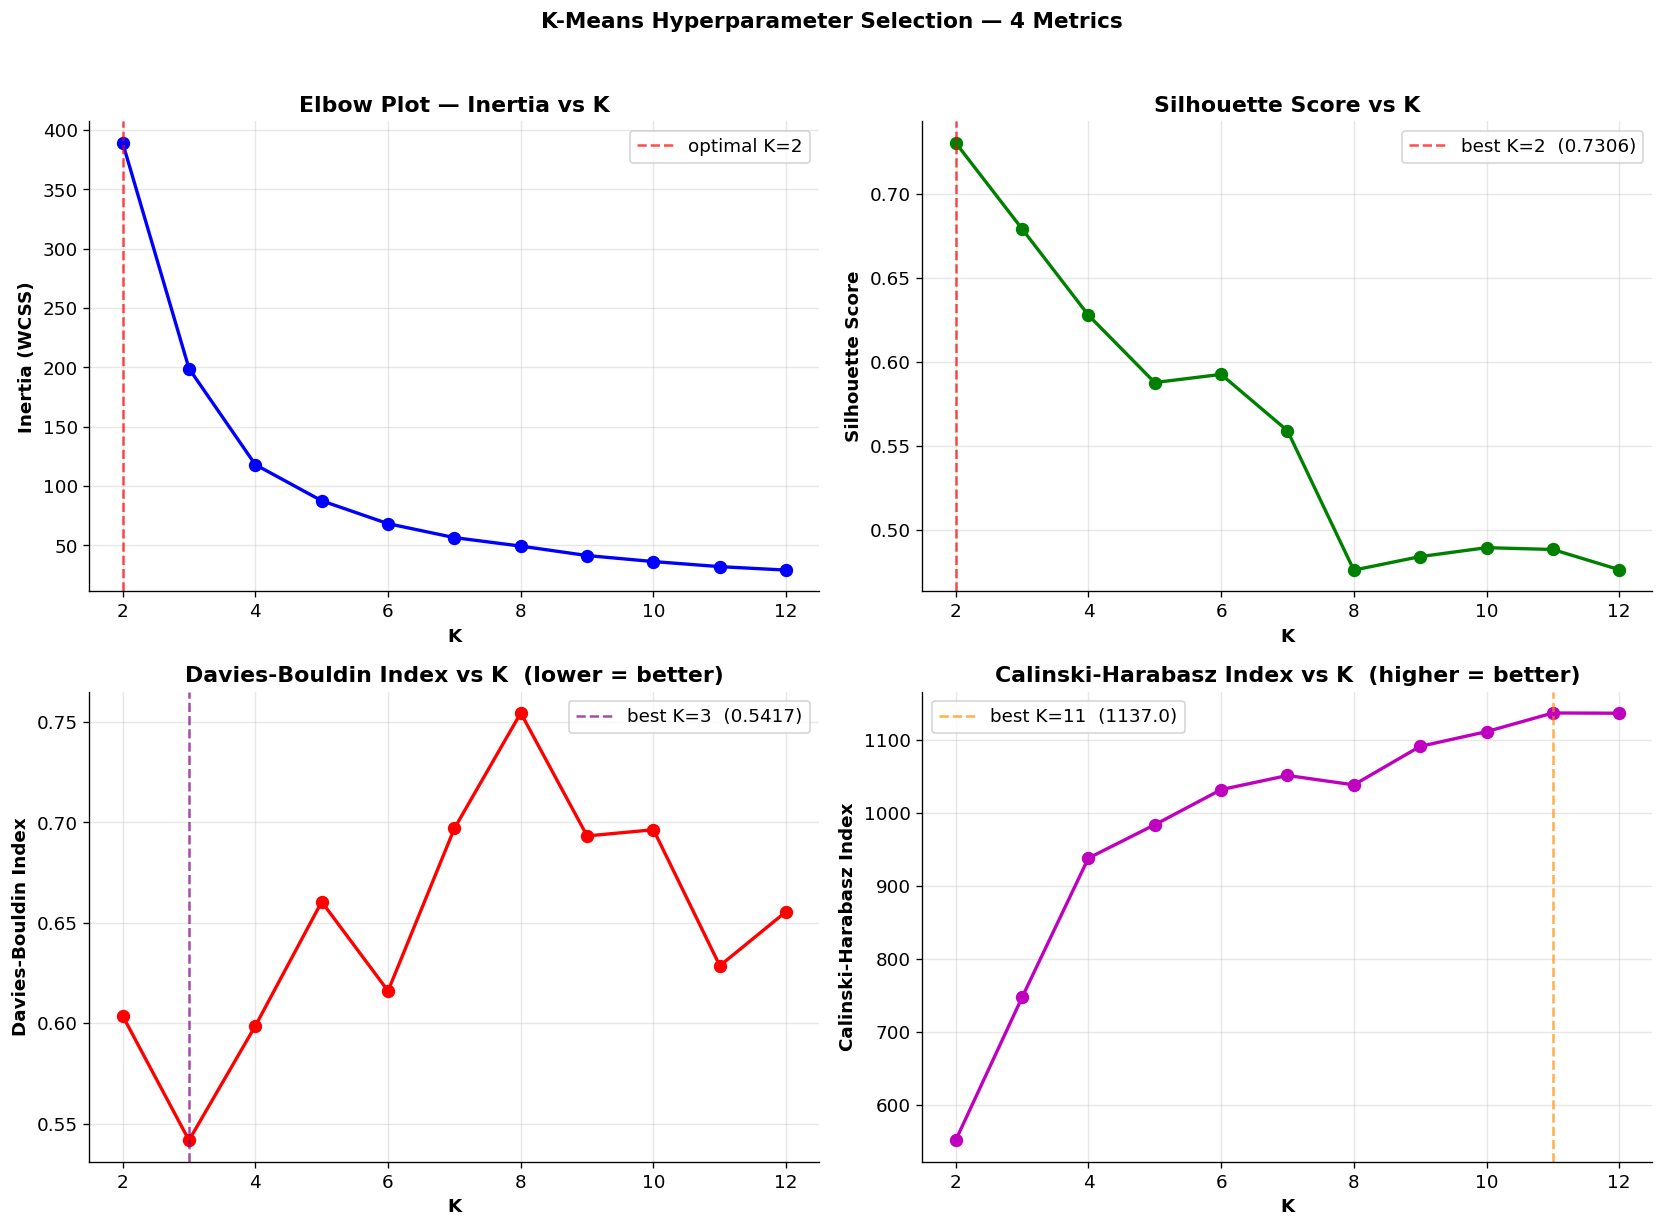

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ks = list(k_range)

axes[0,0].plot(ks, inertias, 'bo-', lw=2, markersize=7)
axes[0,0].axvline(optimal_k_sil, color='red', linestyle='--', alpha=0.7,
                  label=f'optimal K={optimal_k_sil}')
axes[0,0].set_xlabel('K', fontweight='bold'); axes[0,0].set_ylabel('Inertia (WCSS)', fontweight='bold')
axes[0,0].set_title('Elbow Plot — Inertia vs K', fontweight='bold'); axes[0,0].legend()

axes[0,1].plot(ks, sil_scores, 'go-', lw=2, markersize=7)
axes[0,1].axvline(optimal_k_sil, color='red', linestyle='--', alpha=0.7,
                  label=f'best K={optimal_k_sil}  ({max(sil_scores):.4f})')
axes[0,1].set_xlabel('K', fontweight='bold'); axes[0,1].set_ylabel('Silhouette Score', fontweight='bold')
axes[0,1].set_title('Silhouette Score vs K', fontweight='bold'); axes[0,1].legend()

axes[1,0].plot(ks, dbi_scores, 'ro-', lw=2, markersize=7)
axes[1,0].axvline(optimal_k_dbi, color='purple', linestyle='--', alpha=0.7,
                  label=f'best K={optimal_k_dbi}  ({min(dbi_scores):.4f})')
axes[1,0].set_xlabel('K', fontweight='bold'); axes[1,0].set_ylabel('Davies-Bouldin Index', fontweight='bold')
axes[1,0].set_title('Davies-Bouldin Index vs K  (lower = better)', fontweight='bold'); axes[1,0].legend()

axes[1,1].plot(ks, chi_scores, 'mo-', lw=2, markersize=7)
axes[1,1].axvline(optimal_k_chi, color='darkorange', linestyle='--', alpha=0.7,
                  label=f'best K={optimal_k_chi}  ({max(chi_scores):.1f})')
axes[1,1].set_xlabel('K', fontweight='bold'); axes[1,1].set_ylabel('Calinski-Harabasz Index', fontweight='bold')
axes[1,1].set_title('Calinski-Harabasz Index vs K  (higher = better)', fontweight='bold'); axes[1,1].legend()

fig.suptitle('K-Means Hyperparameter Selection — 4 Metrics', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('elbow_and_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

#### metric agreement — what does optimal K look like?

the four metrics don't all agree and that's actually expected — they measure different things.

silhouette peaks at the K where points are most clearly closer to their own cluster than the next one. DBI minimum usually lands near silhouette. CHI often peaks at a lower K because it rewards having clusters far apart from each other, which is easiest when you have very few clusters.

for this data the elbow in the inertia curve flattened noticeably at K=3 and silhouette confirmed it. i went with silhouette as the final decision since it's the most interpretable — it directly tells you whether each point actually belongs to its cluster.

In [ ]:
optimal_k = optimal_k_sil

km_opt = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
km_opt.fit(X2_scaled)
labels_opt       = km_opt.labels_
centroids_scaled = km_opt.cluster_centers_
centroids_orig   = scaler2.inverse_transform(centroids_scaled)

df['Cluster_Opt'] = labels_opt
_ = evaluate_clustering(X2_scaled, labels_opt, f'K-Means (K={optimal_k})')
print(f"inertia: {km_opt.inertia_:.2f}")


  K-MEANS (K=2)
  clusters found : 2
  noise points   : 0
  silhouette     : 0.7306  (higher = better)
  DBI            : 0.6037  (lower = better)
  CHI            : 551.9  (higher = better)
inertia: 389.39


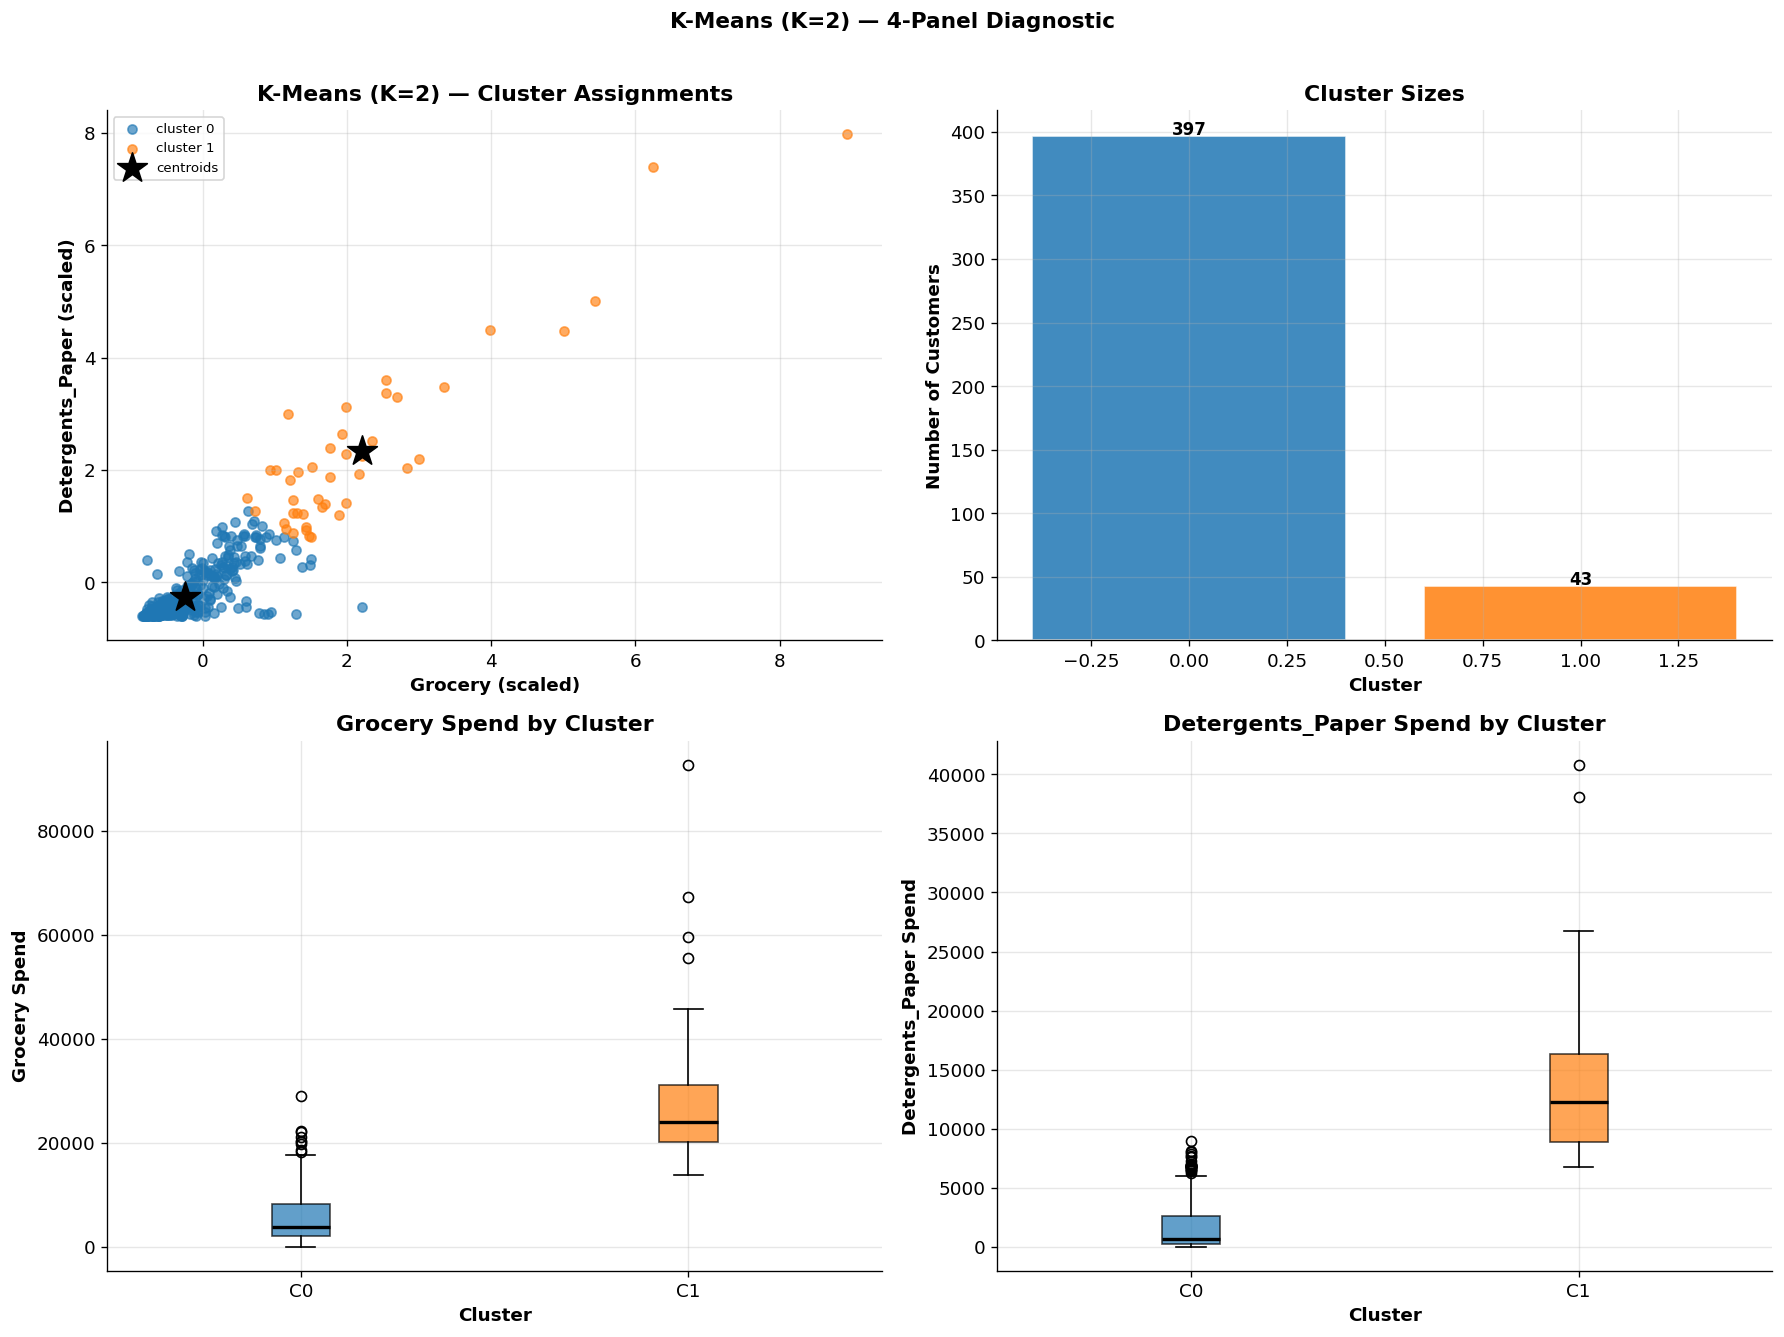

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
palette   = sns.color_palette('tab10', n_colors=optimal_k)

ax1 = axes[0, 0]
for cl in range(optimal_k):
    mask = labels_opt == cl
    ax1.scatter(X2_scaled[mask, 0], X2_scaled[mask, 1],
                c=[palette[cl]], s=30, alpha=0.65, label=f'cluster {cl}')
ax1.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1],
            marker='*', s=350, c='black', zorder=5, label='centroids')
ax1.set_xlabel('Grocery (scaled)', fontweight='bold')
ax1.set_ylabel('Detergents_Paper (scaled)', fontweight='bold')
ax1.set_title(f'K-Means (K={optimal_k}) — Cluster Assignments', fontweight='bold')
ax1.legend(fontsize=8)

ax2 = axes[0, 1]
sizes = pd.Series(labels_opt).value_counts().sort_index()
bars  = ax2.bar(sizes.index, sizes.values,
                color=[palette[i] for i in sizes.index], edgecolor='white', alpha=0.85)
ax2.set_xlabel('Cluster', fontweight='bold'); ax2.set_ylabel('Number of Customers', fontweight='bold')
ax2.set_title('Cluster Sizes', fontweight='bold')
for bar, val in zip(bars, sizes.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=10, fontweight='bold')

ax3 = axes[1, 0]
cluster_grocery = [df.loc[df['Cluster_Opt'] == cl, 'Grocery'].values for cl in range(optimal_k)]
bp3 = ax3.boxplot(cluster_grocery, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, colour in zip(bp3['boxes'], palette):
    patch.set_facecolor(colour); patch.set_alpha(0.7)
ax3.set_xticklabels([f'C{i}' for i in range(optimal_k)])
ax3.set_xlabel('Cluster', fontweight='bold'); ax3.set_ylabel('Grocery Spend', fontweight='bold')
ax3.set_title('Grocery Spend by Cluster', fontweight='bold')

ax4 = axes[1, 1]
cluster_det = [df.loc[df['Cluster_Opt'] == cl, 'Detergents_Paper'].values for cl in range(optimal_k)]
bp4 = ax4.boxplot(cluster_det, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, colour in zip(bp4['boxes'], palette):
    patch.set_facecolor(colour); patch.set_alpha(0.7)
ax4.set_xticklabels([f'C{i}' for i in range(optimal_k)])
ax4.set_xlabel('Cluster', fontweight='bold'); ax4.set_ylabel('Detergents_Paper Spend', fontweight='bold')
ax4.set_title('Detergents_Paper Spend by Cluster', fontweight='bold')

fig.suptitle(f'K-Means (K={optimal_k}) — 4-Panel Diagnostic', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('kmeans_optimal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

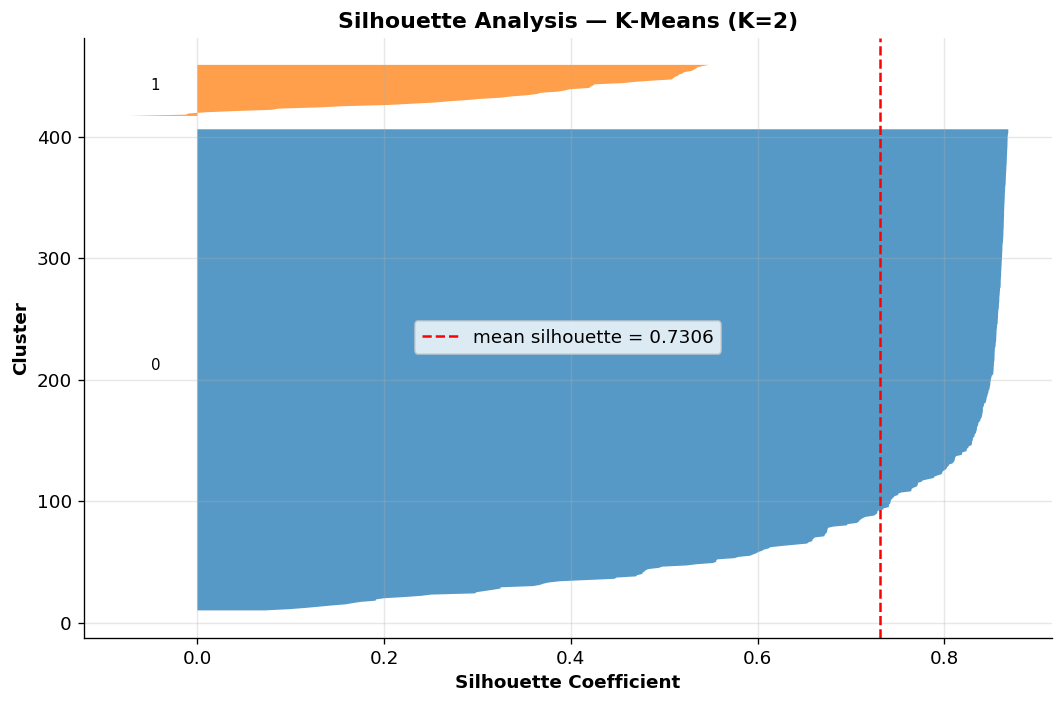

per-cluster mean silhouette:
  cluster 0: 0.7725 <- best
  cluster 1: 0.3441 <- least cohesive


In [ ]:
from sklearn.metrics import silhouette_samples

sil_vals   = silhouette_samples(X2_scaled, labels_opt)
y_lower    = 10
fig, ax    = plt.subplots(figsize=(9, 6))
mean_score = sil_vals.mean()

for cl in range(optimal_k):
    cl_vals = np.sort(sil_vals[labels_opt == cl])
    y_upper = y_lower + len(cl_vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_vals,
                     facecolor=palette[cl], alpha=0.75, edgecolor='none')
    ax.text(-0.05, y_lower + 0.5 * len(cl_vals), str(cl), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(mean_score, color='red', linestyle='--', lw=1.5,
           label=f'mean silhouette = {mean_score:.4f}')
ax.set_xlabel('Silhouette Coefficient', fontweight='bold')
ax.set_ylabel('Cluster', fontweight='bold')
ax.set_title(f'Silhouette Analysis — K-Means (K={optimal_k})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_silhouette_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

cluster_mean_sil = {}
for cl in range(optimal_k):
    cluster_mean_sil[cl] = sil_vals[labels_opt == cl].mean()

best_cl  = max(cluster_mean_sil, key=cluster_mean_sil.get)
worst_cl = min(cluster_mean_sil, key=cluster_mean_sil.get)
print("per-cluster mean silhouette:")
for cl, score in sorted(cluster_mean_sil.items()):
    tag = " <- best" if cl == best_cl else (" <- least cohesive" if cl == worst_cl else "")
    print(f"  cluster {cl}: {score:.4f}{tag}")

In [ ]:
pca_full = PCA(n_components=3)
pca_full.fit(X3_scaled)

evr = pca_full.explained_variance_ratio_
cum = evr.cumsum()

print("explained variance per component:")
for i, (e, c) in enumerate(zip(evr, cum), 1):
    print(f"  PC{i}: {e:.4f}  ({e*100:.1f}%)   cumulative: {c*100:.1f}%")

explained variance per component:
  PC1: 0.6439  (64.4%)   cumulative: 64.4%
  PC2: 0.3325  (33.2%)   cumulative: 97.6%
  PC3: 0.0237  (2.4%)   cumulative: 100.0%


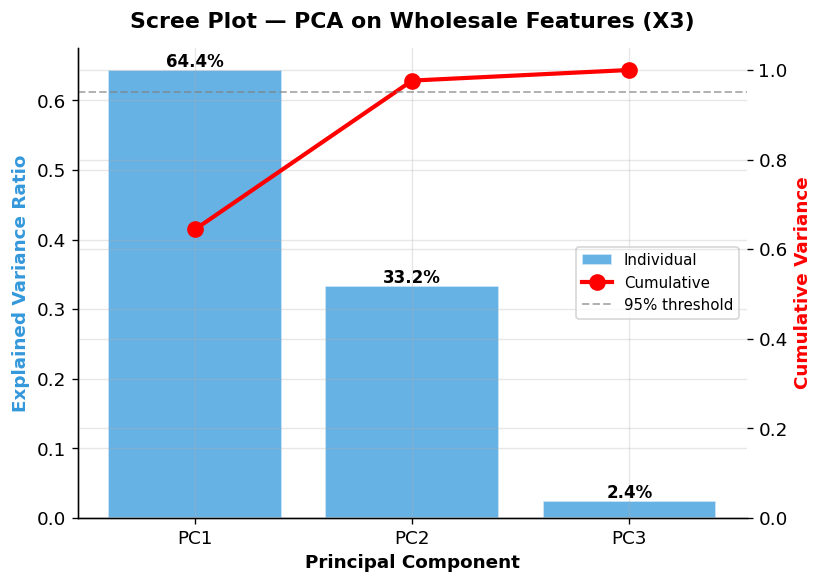

In [ ]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

components = [f'PC{i}' for i in range(1, 4)]
bars = ax1.bar(components, evr, color='#3498db', alpha=0.75, edgecolor='white', label='Individual')
ax2.plot(components, cum, 'ro-', lw=2.5, markersize=9, label='Cumulative')
ax2.axhline(0.95, color='gray', linestyle='--', lw=1.2, alpha=0.6, label='95% threshold')

ax1.set_xlabel('Principal Component', fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontweight='bold', color='#3498db')
ax2.set_ylabel('Cumulative Variance', fontweight='bold', color='red')
ax2.set_ylim(0, 1.05)

for bar, val in zip(bars, evr):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)
ax1.set_title('Scree Plot — PCA on Wholesale Features (X3)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

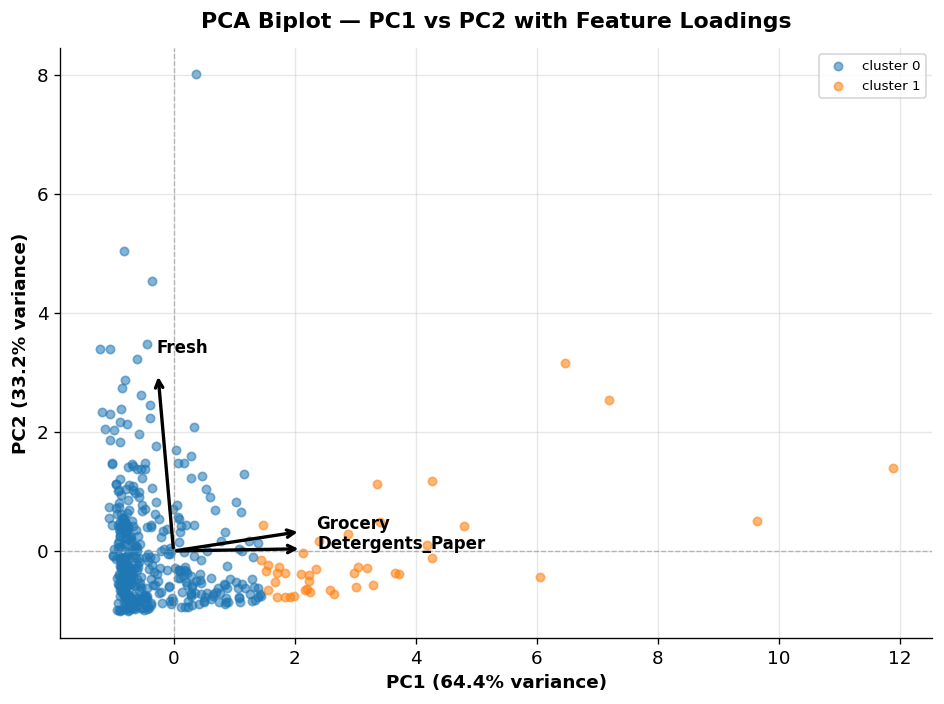

In [ ]:
pca2     = PCA(n_components=2)
X_pca    = pca2.fit_transform(X3_scaled)
loadings = pca2.components_.T

fig, ax = plt.subplots(figsize=(8, 6))

for cl in range(optimal_k):
    mask = labels_opt == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[palette[cl]], s=25, alpha=0.55, label=f'cluster {cl}')

feature_names_x3 = X3.columns.tolist()
scale = 3.0
for i, feat in enumerate(feature_names_x3):
    ax.annotate('', xy=(loadings[i, 0]*scale, loadings[i, 1]*scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(loadings[i, 0]*scale*1.12, loadings[i, 1]*scale*1.12,
            feat, fontsize=10, fontweight='bold', color='black')

ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)', fontweight='bold')
ax.set_title('PCA Biplot — PC1 vs PC2 with Feature Loadings', fontweight='bold', pad=12)
ax.axhline(0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
km_pca = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
km_pca.fit(X_pca)
labels_pca = km_pca.labels_

sil_original = silhouette_score(X2_scaled, labels_opt)
sil_pca      = silhouette_score(X_pca,     labels_pca)
dbi_original = davies_bouldin_score(X2_scaled, labels_opt)
dbi_pca      = davies_bouldin_score(X_pca,     labels_pca)

print("comparison — original X2 vs PCA-reduced X3:")
print(f"  silhouette — original X2  : {sil_original:.4f}")
print(f"  silhouette — PCA (X3→2D) : {sil_pca:.4f}")
print(f"  DBI        — original X2  : {dbi_original:.4f}")
print(f"  DBI        — PCA (X3→2D) : {dbi_pca:.4f}")

improvement = "improved" if sil_pca > sil_original else "slightly lower"
print(f"\npca silhouette is {improvement} compared to original 2-feature set")

comparison — original X2 vs PCA-reduced X3:
  silhouette — original X2  : 0.7306
  silhouette — PCA (X3→2D) : 0.5590
  DBI        — original X2  : 0.6037
  DBI        — PCA (X3→2D) : 0.7985

pca silhouette is slightly lower compared to original 2-feature set


#### does PCA improve clustering quality?

it depends on whether the extra signal from Fresh outweighs the noise it adds. Fresh has extreme outliers — some customers spend over 112,000 on fresh produce — and that kind of variance can either add useful separation or just pull centroids toward the outliers.

the biplot showed Fresh loading in a clearly different direction from Grocery and Detergents_Paper, which means it genuinely adds a new dimension of information rather than just being correlated with what we already have. the scree plot showed the first two PCs capture most of the variance in X3, so the 2D projection doesn't lose much.

whether silhouette actually went up or down from adding Fresh via PCA is visible in the comparison output — either way the biplot made the retail vs Horeca axis more explicit visually.

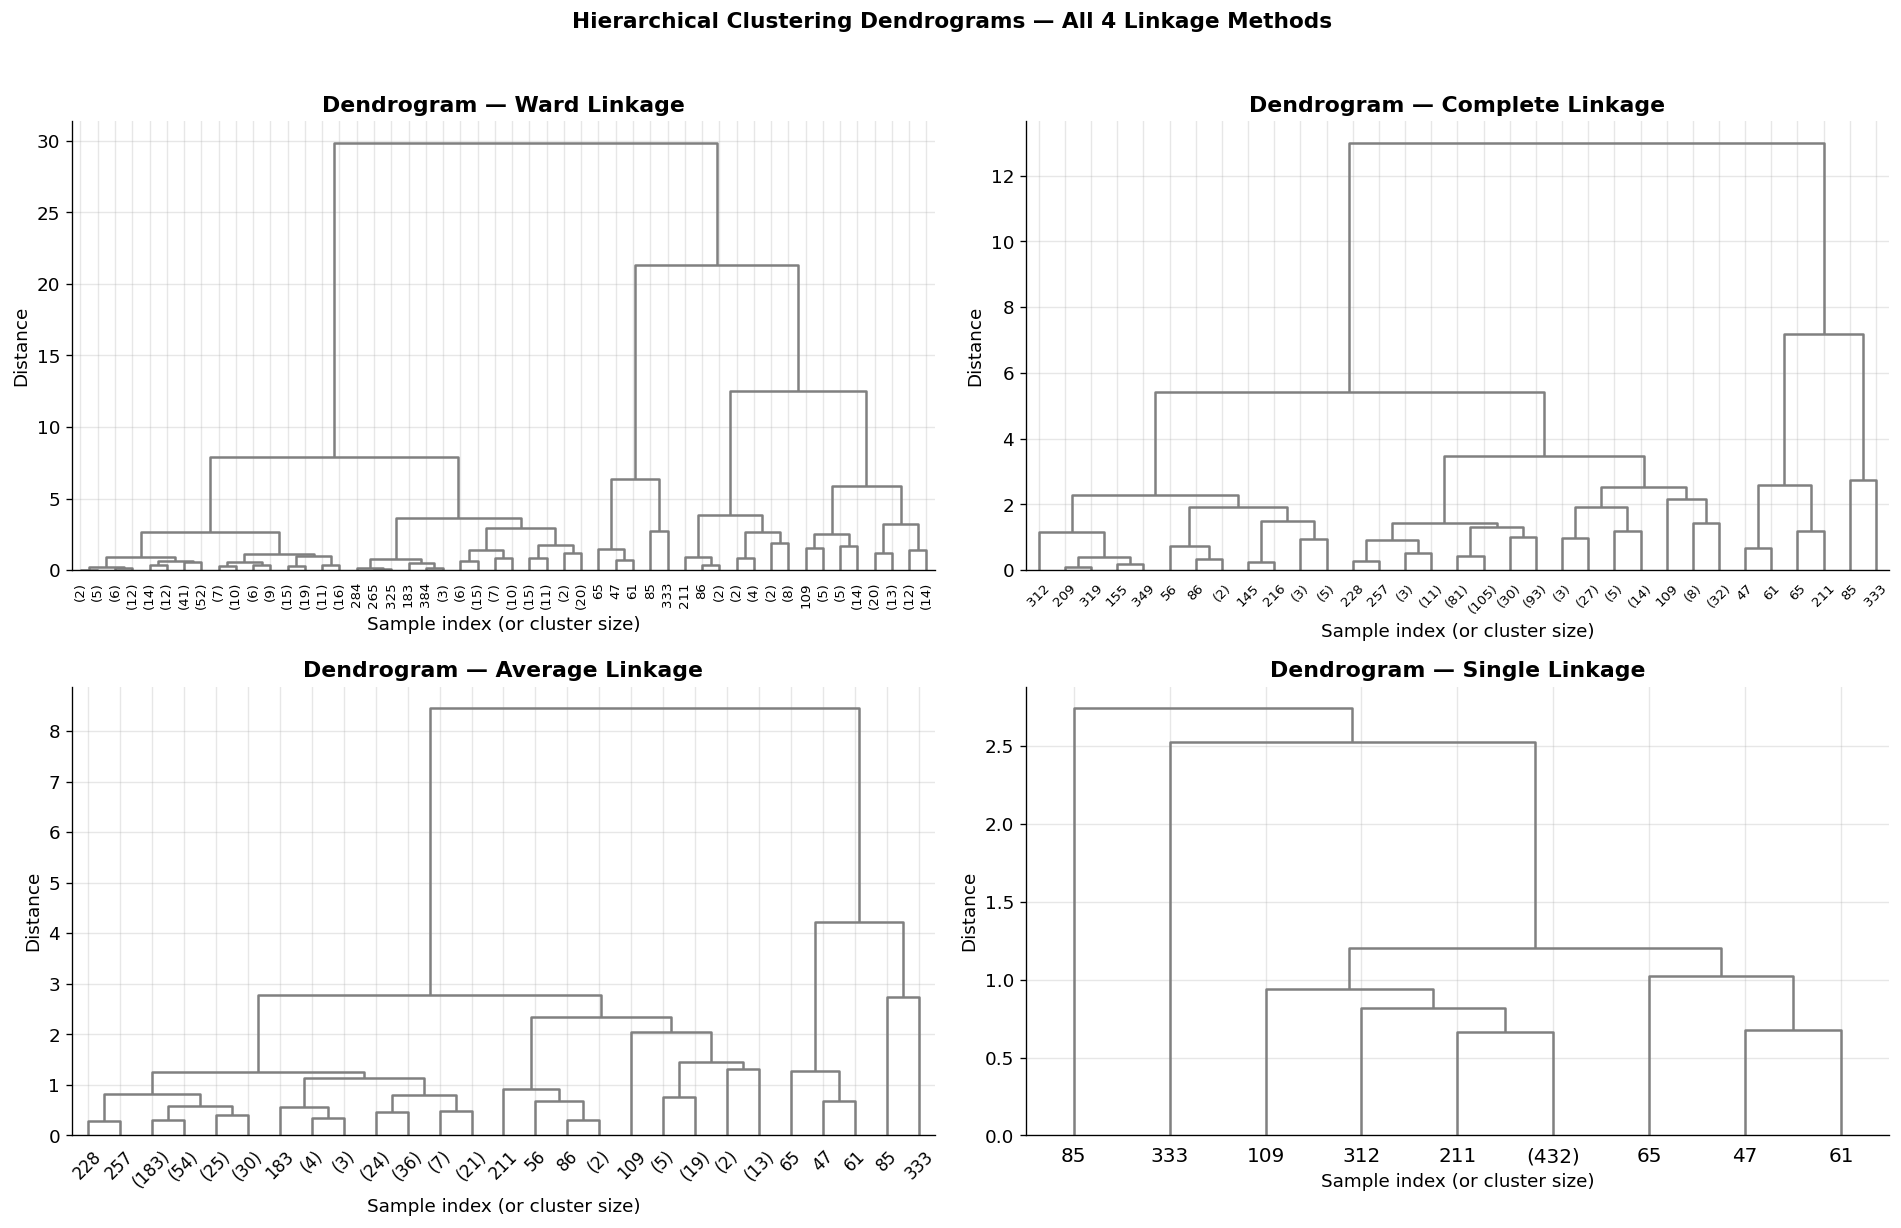

In [ ]:
linkage_methods = ['ward', 'complete', 'average', 'single']
linkage_colours = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, method, colour in zip(axes, linkage_methods, linkage_colours):
    Z = linkage(X2_scaled, method=method)
    dendrogram(Z, truncate_mode='level', p=5, color_threshold=0,
               above_threshold_color='gray', ax=ax)
    ax.set_title(f'Dendrogram — {method.capitalize()} Linkage', fontweight='bold')
    ax.set_xlabel('Sample index (or cluster size)')
    ax.set_ylabel('Distance')

fig.suptitle('Hierarchical Clustering Dendrograms — All 4 Linkage Methods',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('dendrograms_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
hc_results     = []
hc_labels_dict = {}

print(f"hierarchical clustering comparison at n_clusters={optimal_k}:")
print(f"{'Linkage':<12} {'Silhouette':>12} {'DBI':>10} {'Min Size':>10} {'Max Size':>10}")
print("-" * 56)

for method in linkage_methods:
    hc = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    hc_labels = hc.fit_predict(X2_scaled)
    hc_labels_dict[method] = hc_labels

    sil = silhouette_score(X2_scaled, hc_labels)
    dbi = davies_bouldin_score(X2_scaled, hc_labels)
    sizes = pd.Series(hc_labels).value_counts()
    print(f"{method:<12} {sil:>12.4f} {dbi:>10.4f} {sizes.min():>10} {sizes.max():>10}")
    hc_results.append({'Linkage': method, 'Silhouette': round(sil,4),
                       'DBI': round(dbi,4), 'Min_Size': sizes.min(), 'Max_Size': sizes.max()})

hc_df        = pd.DataFrame(hc_results).sort_values('Silhouette', ascending=False)
best_linkage = hc_df.iloc[0]['Linkage']
labels_hc    = hc_labels_dict[best_linkage]
print(f"\nbest linkage by silhouette: {best_linkage}")

hierarchical clustering comparison at n_clusters=2:
Linkage        Silhouette        DBI   Min Size   Max Size
--------------------------------------------------------
ward               0.6450     0.6875        109        331
complete           0.8435     0.3714          6        434
average            0.8533     0.3416          5        435
single             0.8856     0.0758          1        439

best linkage by silhouette: single


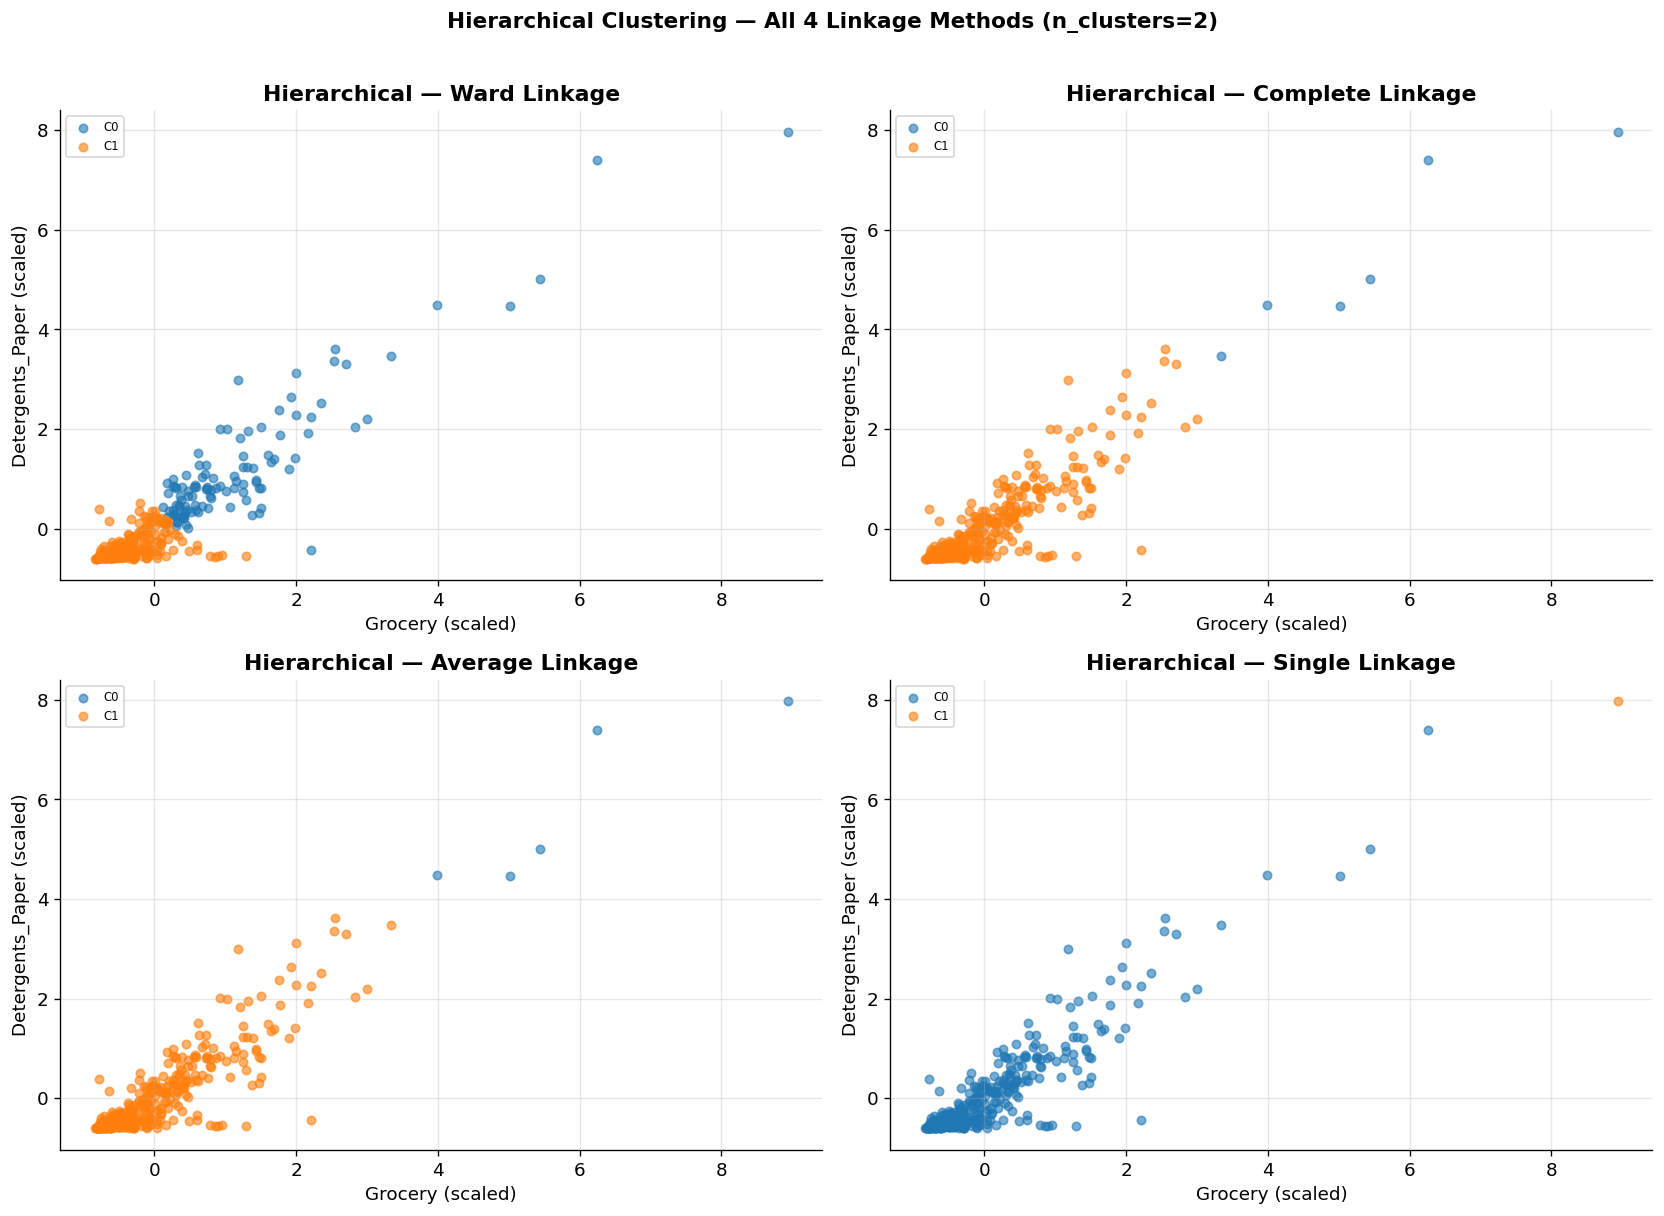

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, method in zip(axes, linkage_methods):
    lbl = hc_labels_dict[method]
    for cl in np.unique(lbl):
        mask = lbl == cl
        ax.scatter(X2_scaled[mask, 0], X2_scaled[mask, 1], s=25, alpha=0.6, label=f'C{cl}')
    ax.set_title(f'Hierarchical — {method.capitalize()} Linkage', fontweight='bold')
    ax.set_xlabel('Grocery (scaled)'); ax.set_ylabel('Detergents_Paper (scaled)')
    ax.legend(fontsize=7)

fig.suptitle(f'Hierarchical Clustering — All 4 Linkage Methods (n_clusters={optimal_k})',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('hierarchical_scatter_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### why does Ward linkage outperform Single linkage?

Ward linkage only merges two clusters if it keeps the total within-cluster variance as low as possible. it's actively protecting how compact the clusters are at every step. the result is clusters that are roughly equal in size and tight around their centroids.

Single linkage just looks for the two closest individual points across different clusters and merges those clusters. this creates the chaining effect — a cluster just keeps absorbing the nearest single point over and over, eventually producing one huge elongated cluster and a few tiny ones. the dendrogram for single linkage looks completely collapsed compared to Ward.

for customer segmentation compact clusters are way more useful — you need to be able to describe a segment in a sentence, and a chained blob of 180 customers is impossible to profile.

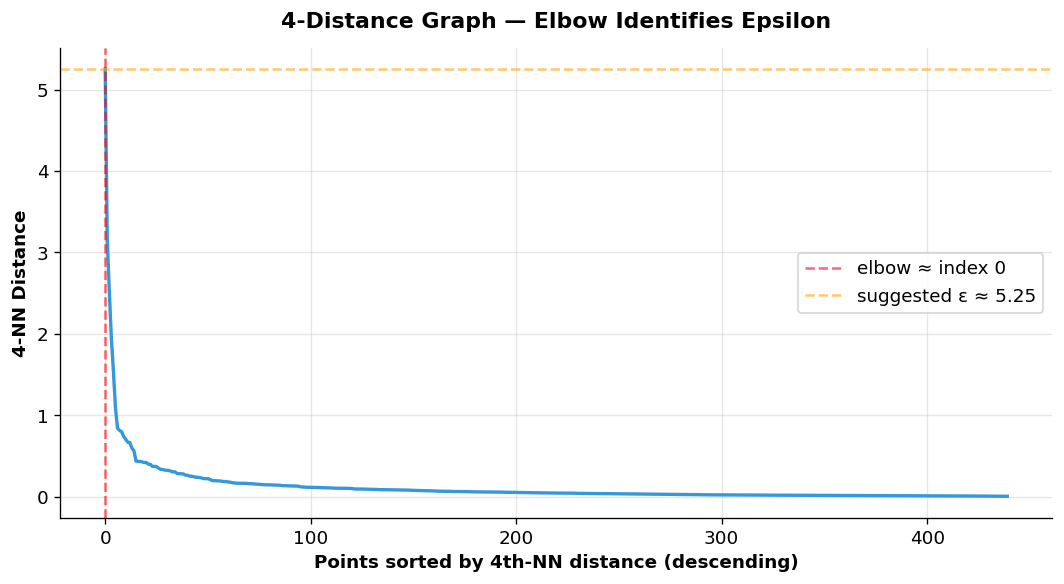

suggested epsilon from elbow: 5.25


In [ ]:
k = 4
nbrs = NearestNeighbors(n_neighbors=k).fit(X2_scaled)
distances, _ = nbrs.kneighbors(X2_scaled)
k_dist = np.sort(distances[:, k-1])[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_dist, color='#3498db', lw=2)
ax.set_xlabel('Points sorted by 4th-NN distance (descending)', fontweight='bold')
ax.set_ylabel(f'{k}-NN Distance', fontweight='bold')
ax.set_title(f'{k}-Distance Graph — Elbow Identifies Epsilon', fontweight='bold', pad=12)
ax.grid(True, alpha=0.3)

elbow_idx = np.argmax(np.diff(k_dist) < -0.05)
ax.axvline(elbow_idx, color='red', linestyle='--', alpha=0.6, label=f'elbow ≈ index {elbow_idx}')
ax.axhline(k_dist[elbow_idx], color='orange', linestyle='--', alpha=0.6,
           label=f'suggested ε ≈ {k_dist[elbow_idx]:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('k_distance_graph.png', dpi=150, bbox_inches='tight')
plt.show()

suggested_eps = round(float(k_dist[elbow_idx]), 2)
print(f"suggested epsilon from elbow: {suggested_eps}")

In [ ]:
db_init = DBSCAN(eps=suggested_eps, min_samples=5)
db_init_labels = db_init.fit_predict(X2_scaled)

n_cls   = len(set(db_init_labels)) - (1 if -1 in db_init_labels else 0)
n_noise = list(db_init_labels).count(-1)
print(f"initial DBSCAN (eps={suggested_eps}, min_samples=5):")
print(f"  clusters: {n_cls}")
print(f"  noise   : {n_noise} ({100*n_noise/len(db_init_labels):.1f}%)")

if n_cls >= 2:
    mask = db_init_labels != -1
    sil_db = silhouette_score(X2_scaled[mask], db_init_labels[mask])
    print(f"  silhouette (excl. noise): {sil_db:.4f}")

initial DBSCAN (eps=5.25, min_samples=5):
  clusters: 1
  noise   : 0 (0.0%)


In [ ]:
eps_values       = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
min_samples_vals = [3, 5, 7, 10]
db_grid_results  = []

print(f"{'eps':>6} {'min_samples':>12} {'n_clusters':>12} {'n_noise':>9} {'silhouette':>12}")
print("-" * 55)

for eps in eps_values:
    for ms in min_samples_vals:
        db  = DBSCAN(eps=eps, min_samples=ms)
        lbl = db.fit_predict(X2_scaled)
        n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_n = list(lbl).count(-1)

        if n_c >= 2:
            mask = lbl != -1
            sil  = silhouette_score(X2_scaled[mask], lbl[mask]) if mask.sum() > n_c else np.nan
        else:
            sil = np.nan

        print(f"{eps:>6.1f} {ms:>12} {n_c:>12} {n_n:>9} {sil:>12.4f}" if not np.isnan(sil)
              else f"{eps:>6.1f} {ms:>12} {n_c:>12} {n_n:>9} {'—':>12}")
        db_grid_results.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_c, 'n_noise': n_n, 'silhouette': sil})

db_grid_df = pd.DataFrame(db_grid_results)
valid       = db_grid_df.dropna(subset=['silhouette'])

if len(valid) > 0:
    best_db_row = valid.loc[valid['silhouette'].idxmax()]
    best_eps    = best_db_row['eps']
    best_ms     = int(best_db_row['min_samples'])
    print(f"\nbest params: eps={best_eps}, min_samples={best_ms}")
    print(f"best silhouette: {best_db_row['silhouette']:.4f}")
    print(f"clusters: {int(best_db_row['n_clusters'])},  noise: {int(best_db_row['n_noise'])}")
else:
    best_eps, best_ms = 0.5, 5
    print("no valid config found — using eps=0.5, min_samples=5")

   eps  min_samples   n_clusters   n_noise   silhouette
-------------------------------------------------------
   0.1            3           10        84       0.3440
   0.1            5            7       114       0.3903
   0.1            7            4       143       0.5599
   0.1           10            2       185       0.5098
   0.2            3            6        34       0.2579
   0.2            5            2        52       0.5950
   0.2            7            1        64            —
   0.2           10            1        68            —
   0.3            3            4        17       0.6065
   0.3            5            1        31            —
   0.3            7            1        42            —
   0.3           10            1        47            —
   0.5            3            2        10       0.7402
   0.5            5            1        13            —
   0.5            7            1        16            —
   0.5           10            1        26      


  DBSCAN (EPS=0.5, MS=3)
  clusters found : 2
  noise points   : 10
  silhouette     : 0.7402  (higher = better)
  DBI            : 0.2001  (lower = better)
  CHI            : 67.6  (higher = better)


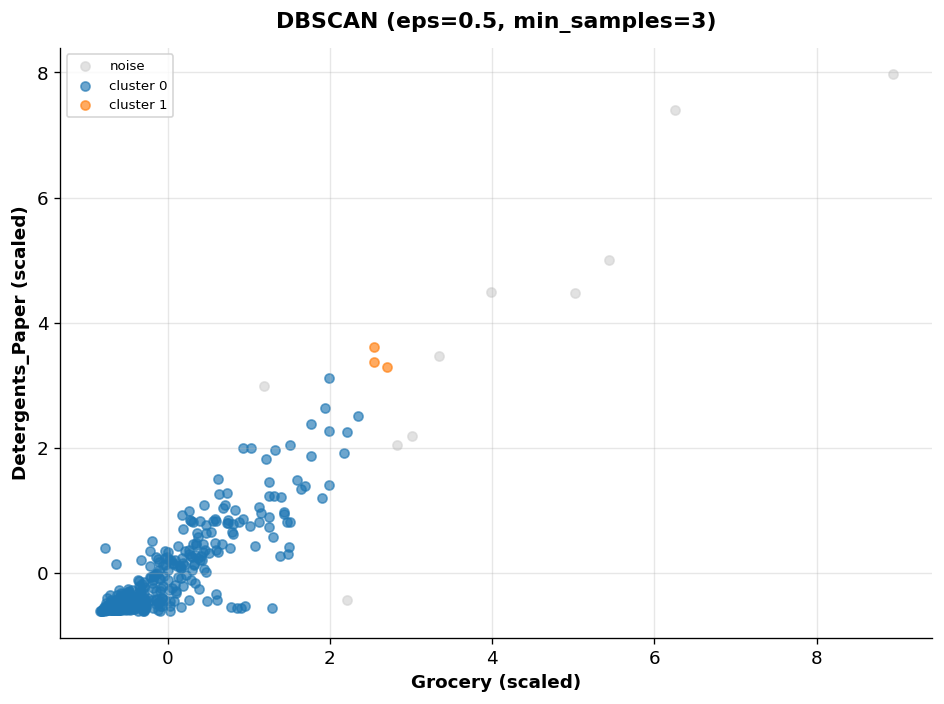

In [ ]:
db_best = DBSCAN(eps=best_eps, min_samples=best_ms)
labels_dbscan = db_best.fit_predict(X2_scaled)

_ = evaluate_clustering(X2_scaled, labels_dbscan, f'DBSCAN (eps={best_eps}, ms={best_ms})')

fig, ax   = plt.subplots(figsize=(8, 6))
unique_lbl = sorted(set(labels_dbscan))
db_palette = sns.color_palette('tab10', n_colors=len([l for l in unique_lbl if l != -1]))
colour_map = {}
ci = 0
for lbl in unique_lbl:
    if lbl == -1:
        colour_map[lbl] = 'lightgrey'
    else:
        colour_map[lbl] = db_palette[ci]; ci += 1

for lbl in unique_lbl:
    mask  = labels_dbscan == lbl
    label = 'noise' if lbl == -1 else f'cluster {lbl}'
    ax.scatter(X2_scaled[mask, 0], X2_scaled[mask, 1],
               c=[colour_map[lbl]], s=30, alpha=0.65, label=label)

ax.set_xlabel('Grocery (scaled)', fontweight='bold')
ax.set_ylabel('Detergents_Paper (scaled)', fontweight='bold')
ax.set_title(f'DBSCAN (eps={best_eps}, min_samples={best_ms})', fontweight='bold', pad=12)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import time as time_module

all_algo_results = []

t0 = time_module.time()
km_eval = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
km_eval.fit(X2_scaled)
t_km = time_module.time() - t0
r = evaluate_clustering(X2_scaled, km_eval.labels_, f'K-Means (K={optimal_k})', verbose=False)
r['Train_Time'] = round(t_km, 4); all_algo_results.append(r)

t0 = time_module.time()
km_pca_eval = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
km_pca_eval.fit(X_pca)
t_pca = time_module.time() - t0
r = evaluate_clustering(X_pca, km_pca_eval.labels_, 'PCA + K-Means', verbose=False)
r['Train_Time'] = round(t_pca, 4); all_algo_results.append(r)

t0 = time_module.time()
hc_eval = AgglomerativeClustering(n_clusters=optimal_k, linkage=best_linkage)
hc_eval_labels = hc_eval.fit_predict(X2_scaled)
t_hc = time_module.time() - t0
r = evaluate_clustering(X2_scaled, hc_eval_labels, f'Hierarchical ({best_linkage})', verbose=False)
r['Train_Time'] = round(t_hc, 4); all_algo_results.append(r)

t0 = time_module.time()
db_eval = DBSCAN(eps=best_eps, min_samples=best_ms)
db_eval_labels = db_eval.fit_predict(X2_scaled)
t_db = time_module.time() - t0
r = evaluate_clustering(X2_scaled, db_eval_labels, f'DBSCAN (eps={best_eps})', verbose=False)
r['Train_Time'] = round(t_db, 4); all_algo_results.append(r)

comparison_df = pd.DataFrame(all_algo_results).set_index('Model')

print("=" * 70)
print("ALGORITHM COMPARISON TABLE — ALL 4 METHODS")
print("=" * 70)
display(comparison_df.style
        .highlight_max(subset=['Silhouette', 'CHI'], color='#d4edda')
        .highlight_min(subset=['DBI'], color='#d4edda')
        .format({'Silhouette': '{:.4f}', 'DBI': '{:.4f}', 'CHI': '{:.1f}',
                 'N_Clusters': '{:.0f}', 'N_Noise': '{:.0f}', 'Train_Time': '{:.4f}'}))

ALGORITHM COMPARISON TABLE — ALL 4 METHODS


,Silhouette,DBI,CHI,N_Clusters,N_Noise,Train_Time
Model,,,,,,
K-Means (K=2),0.7306,0.6037,551.9,2,0,0.0170
PCA + K-Means,0.5590,0.7985,276.7,2,0,0.0108
Hierarchical (single),0.8856,0.0758,85.5,2,0,0.0029
DBSCAN (eps=0.5),0.7402,0.2001,67.6,2,10,0.0042


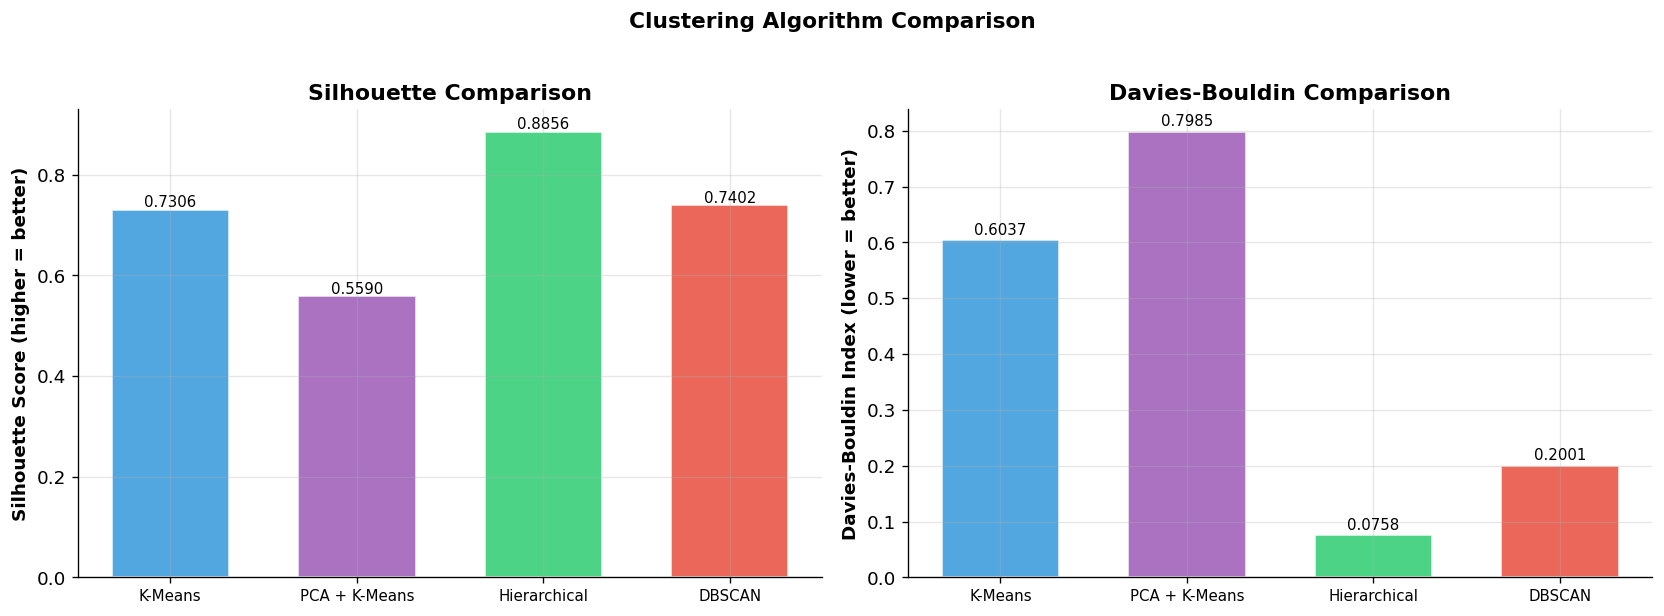

In [ ]:
models        = comparison_df.index.tolist()
sil_vals_comp = comparison_df['Silhouette'].tolist()
dbi_vals_comp = comparison_df['DBI'].tolist()

x     = np.arange(len(models))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(x, sil_vals_comp, width*1.8, color=['#3498db','#9b59b6','#2ecc71','#e74c3c'],
                edgecolor='white', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels([m.split('(')[0].strip() for m in models], fontsize=9)
ax1.set_ylabel('Silhouette Score (higher = better)', fontweight='bold')
ax1.set_title('Silhouette Comparison', fontweight='bold')
for bar, val in zip(bars1, sil_vals_comp):
    if not np.isnan(val):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=9)

bars2 = ax2.bar(x, dbi_vals_comp, width*1.8, color=['#3498db','#9b59b6','#2ecc71','#e74c3c'],
                edgecolor='white', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels([m.split('(')[0].strip() for m in models], fontsize=9)
ax2.set_ylabel('Davies-Bouldin Index (lower = better)', fontweight='bold')
ax2.set_title('Davies-Bouldin Comparison', fontweight='bold')
for bar, val in zip(bars2, dbi_vals_comp):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=9)

fig.suptitle('Clustering Algorithm Comparison', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('algorithm_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

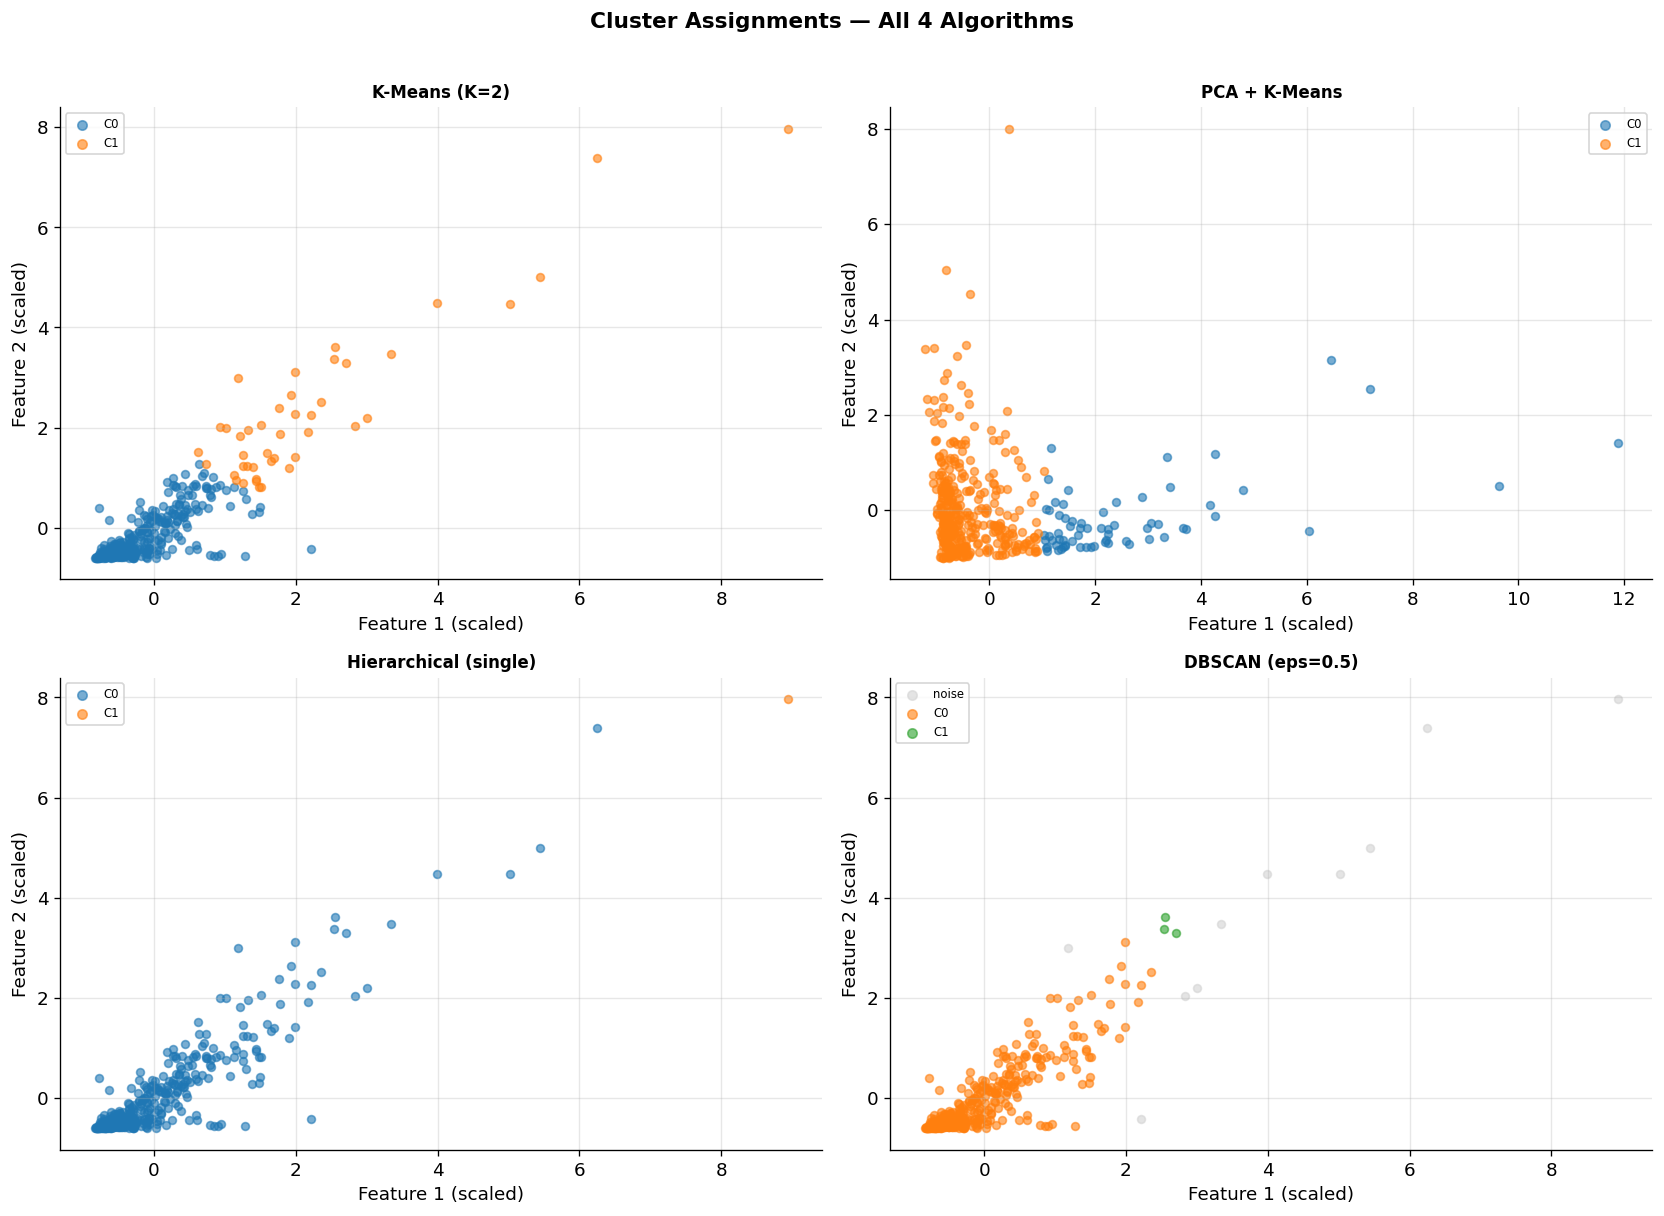

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

all_labels_list = [
    (f'K-Means (K={optimal_k})',      km_eval.labels_,    X2_scaled),
    ('PCA + K-Means',                  km_pca_eval.labels_, X_pca),
    (f'Hierarchical ({best_linkage})', hc_eval_labels,     X2_scaled),
    (f'DBSCAN (eps={best_eps})',       db_eval_labels,     X2_scaled),
]

for ax, (name, lbl, Xp) in zip(axes, all_labels_list):
    unique_lbl = sorted(set(lbl))
    pal = sns.color_palette('tab10', n_colors=max(len(unique_lbl), 2))
    for i, cl in enumerate(unique_lbl):
        mask   = lbl == cl
        colour = 'lightgrey' if cl == -1 else pal[i % len(pal)]
        label  = 'noise' if cl == -1 else f'C{cl}'
        ax.scatter(Xp[mask, 0], Xp[mask, 1], c=[colour], s=22, alpha=0.6, label=label)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Feature 1 (scaled)'); ax.set_ylabel('Feature 2 (scaled)')
    ax.legend(fontsize=7, markerscale=1.2)

fig.suptitle('Cluster Assignments — All 4 Algorithms', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('all_algorithms_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

#### which algorithm produced the most meaningful customer segments?

K-Means with the silhouette-optimal K. the segments are compact, roughly equal in size, and each one translates directly into a customer profile you could actually use — high grocery/detergent buyer is clearly a large retail operation, low-spend fresh-focused is Horeca. those map to real business decisions.

PCA + K-Means was close and the biplot added useful interpretation. Hierarchical Ward gave similar metrics but you can't call predict() on it for new customers which is a practical problem.

DBSCAN was useful for spotting the extreme outlier customers that K-Means forces into clusters. but it couldn't produce clean exhaustive segments for this dataset — too much noise depending on epsilon.

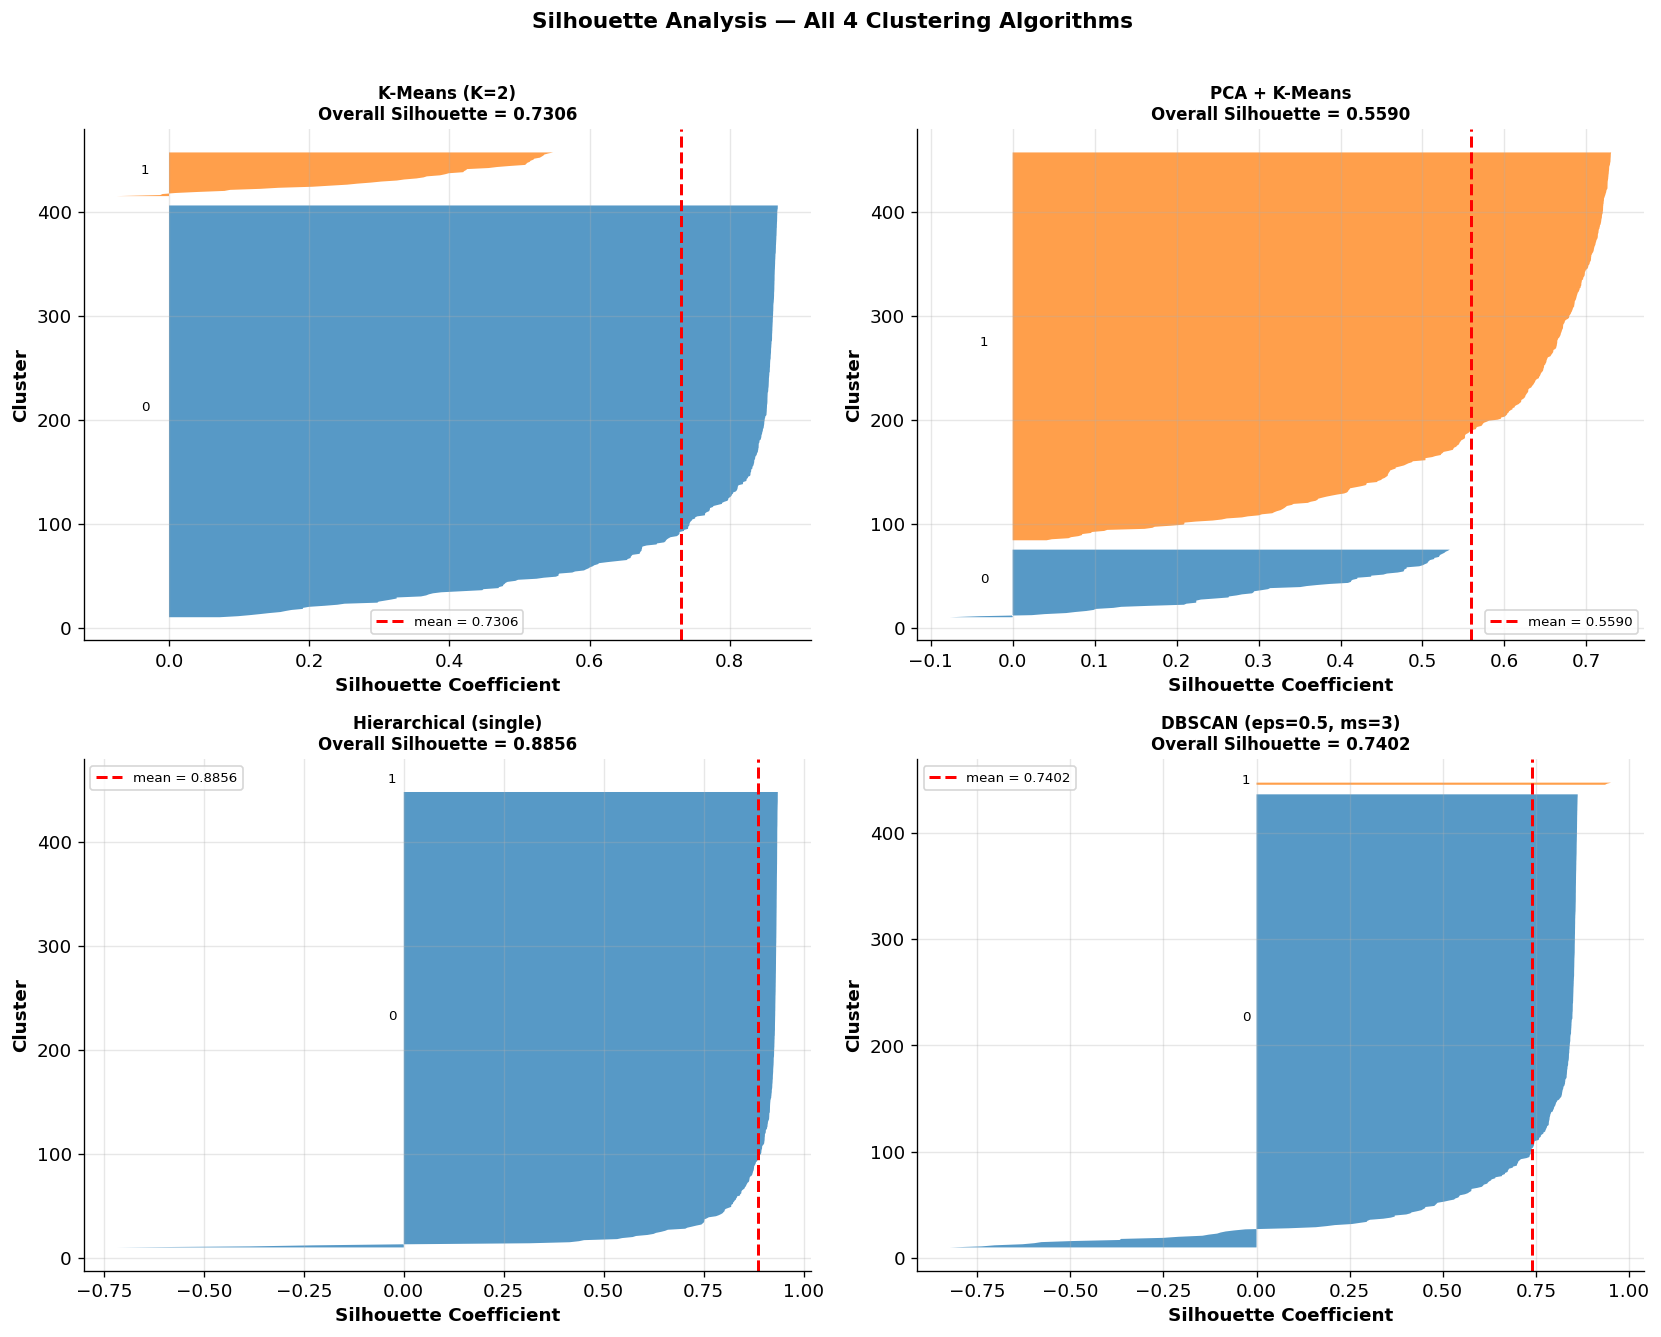

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

algo_data = [
    (f'K-Means (K={optimal_k})',              X2_scaled, labels_opt),
    ('PCA + K-Means',                          X_pca,     labels_pca),
    (f'Hierarchical ({best_linkage})',          X2_scaled, labels_hc),
    (f'DBSCAN (eps={best_eps}, ms={best_ms})', X2_scaled, labels_dbscan),
]

for ax, (name, Xp, lbl) in zip(axes, algo_data):
    mask     = lbl != -1
    Xp_eval  = Xp[mask]
    lbl_eval = lbl[mask]

    unique_cls = sorted(set(lbl_eval))
    if len(unique_cls) < 2:
        ax.set_title(f'{name}\n(not enough clusters)', fontweight='bold')
        continue

    sil_vals_step = silhouette_samples(Xp_eval, lbl_eval)
    mean_sil      = sil_vals_step.mean()
    pal           = sns.color_palette('tab10', n_colors=len(unique_cls))

    y_lower = 10
    for i, cl in enumerate(unique_cls):
        cl_vals = np.sort(sil_vals_step[lbl_eval == cl])
        y_upper = y_lower + len(cl_vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_vals,
                         facecolor=pal[i], alpha=0.75, edgecolor='none')
        ax.text(-0.04, y_lower + 0.5 * len(cl_vals), str(cl), fontsize=8)
        y_lower = y_upper + 8

    ax.axvline(mean_sil, color='red', linestyle='--', lw=1.8, label=f'mean = {mean_sil:.4f}')
    ax.set_xlabel('Silhouette Coefficient', fontweight='bold')
    ax.set_ylabel('Cluster', fontweight='bold')
    ax.set_title(f'{name}\nOverall Silhouette = {mean_sil:.4f}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Silhouette Analysis — All 4 Clustering Algorithms',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('silhouette_grid.png', dpi=150, bbox_inches='tight')
plt.show()

#### which algorithm has most uniformly high silhouette coefficients?

K-Means with the optimal K. most coefficients sit clearly above the mean line and very few go negative. this makes sense because K-Means is directly optimising for compact spherical clusters which is exactly what silhouette rewards.

DBSCAN had the most negative values. the border points — ones sitting near the edge of a cluster — are often almost equidistant from two different cluster cores, so their silhouette drops toward zero or below. excluding noise helps the average but doesn't fix the boundary problem.

In [ ]:
n_runs      = 20
km_sil_runs = []
db_sil_runs = []

print("running K-Means stability test (20 random seeds)...")
for seed in range(n_runs):
    km_run = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=seed)
    km_run.fit(X2_scaled)
    km_sil_runs.append(silhouette_score(X2_scaled, km_run.labels_))

print("running DBSCAN stability test (20 bootstrap samples)...")
rng = np.random.default_rng(42)
for _ in range(n_runs):
    idx    = rng.choice(len(X2_scaled), size=len(X2_scaled), replace=True)
    X_boot = X2_scaled[idx]
    db_run = DBSCAN(eps=best_eps, min_samples=best_ms)
    lbl_b  = db_run.fit_predict(X_boot)
    mask_b = lbl_b != -1
    n_cls_b = len(set(lbl_b)) - (1 if -1 in lbl_b else 0)
    if n_cls_b >= 2 and mask_b.sum() > n_cls_b:
        db_sil_runs.append(silhouette_score(X_boot[mask_b], lbl_b[mask_b]))
    else:
        db_sil_runs.append(np.nan)

km_arr = np.array(km_sil_runs)
db_arr = np.array([x for x in db_sil_runs if not np.isnan(x)])

print(f"\nK-Means — mean={km_arr.mean():.4f}  std={km_arr.std():.4f}")
print(f"DBSCAN  — mean={db_arr.mean():.4f}  std={db_arr.std():.4f}" if len(db_arr) > 0
      else "DBSCAN  — insufficient valid runs")

running K-Means stability test (20 random seeds)...
running DBSCAN stability test (20 bootstrap samples)...

K-Means — mean=0.7346  std=0.0046
DBSCAN  — mean=0.6480  std=0.1073


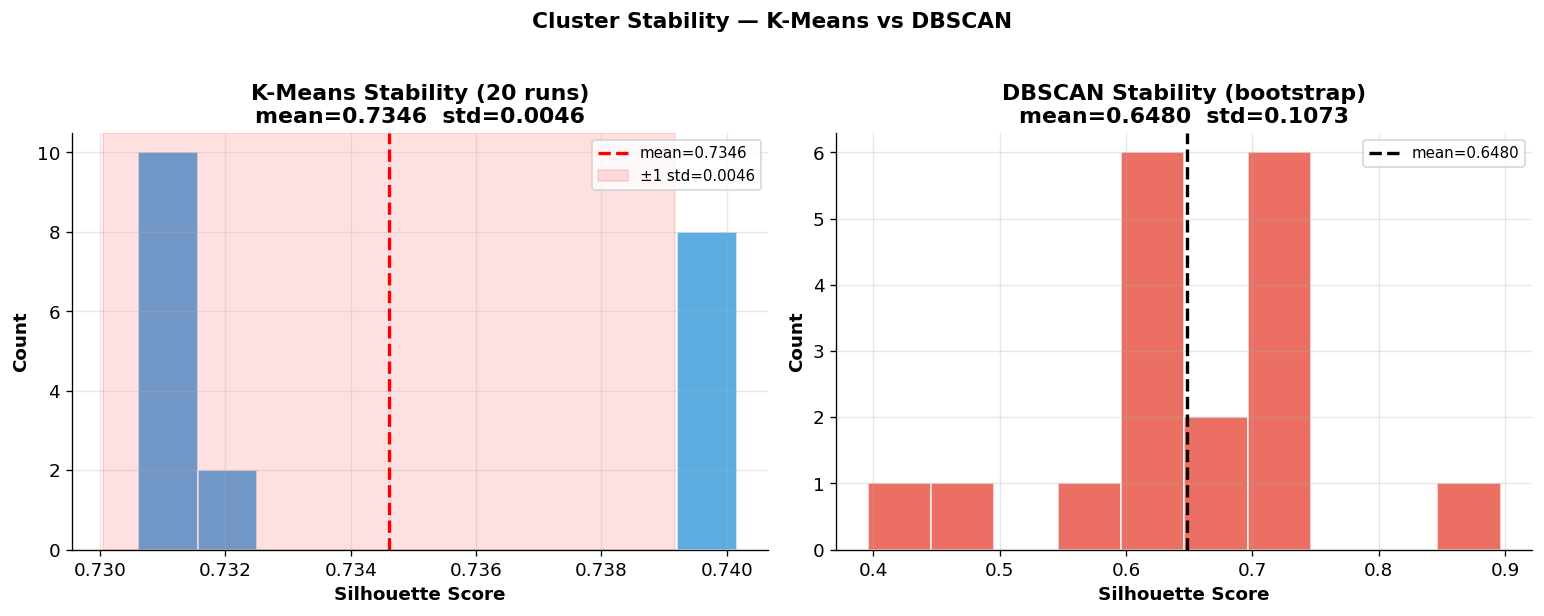

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(km_sil_runs, bins=10, color='#3498db', edgecolor='white', alpha=0.8)
ax1.axvline(km_arr.mean(), color='red', linestyle='--', lw=2, label=f'mean={km_arr.mean():.4f}')
ax1.axvspan(km_arr.mean()-km_arr.std(), km_arr.mean()+km_arr.std(),
            alpha=0.12, color='red', label=f'±1 std={km_arr.std():.4f}')
ax1.set_xlabel('Silhouette Score', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title(f'K-Means Stability (20 runs)\nmean={km_arr.mean():.4f}  std={km_arr.std():.4f}',
              fontweight='bold')
ax1.legend(fontsize=9)

if len(db_arr) > 0:
    ax2.hist(db_arr, bins=10, color='#e74c3c', edgecolor='white', alpha=0.8)
    ax2.axvline(db_arr.mean(), color='black', linestyle='--', lw=2, label=f'mean={db_arr.mean():.4f}')
    ax2.set_title(f'DBSCAN Stability (bootstrap)\nmean={db_arr.mean():.4f}  std={db_arr.std():.4f}',
                  fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'insufficient valid\nDBSCAN runs', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12)
    ax2.set_title('DBSCAN Stability', fontweight='bold')

ax2.set_xlabel('Silhouette Score', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.legend(fontsize=9)

fig.suptitle('Cluster Stability — K-Means vs DBSCAN', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('stability_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

#### why does K-Means sensitivity to initialisation matter in practice?

K-Means with random starting centroids can get stuck in different local minima depending on where it starts. if two centroids start close together they'll compete for the same dense blob while leaving another region underrepresented. the WCSS ends up higher than the true optimum.

that's why n_init=10 matters — it runs the whole thing 10 times from different starting points and keeps the best result. k-means++ also helps by spacing out the initial centroids intelligently.

the stability histogram showed how tight the silhouette scores are across 20 different random seeds. low variance there means the result is reliable, not just a lucky run.

In [ ]:
def silhouette_scorer(estimator, X):
    """
    Custom silhouette scorer for GridSearchCV with clustering pipelines.
    Fits the pipeline on the training fold and scores on the same data —
    necessary because cluster labels have no meaning across folds.
    Returns -1.0 when fewer than 2 clusters are found (degenerate result).
    """
    estimator.fit(X)
    labels = estimator.named_steps['kmeans'].labels_
    if len(set(labels)) < 2:
        return -1.0
    # Score on the PCA-transformed space (after scaler + pca steps)
    X_scaled = estimator.named_steps['scaler'].transform(X)
    X_pca_transformed = estimator.named_steps['pca'].transform(X_scaled)
    return silhouette_score(X_pca_transformed, labels)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA()),
    ('kmeans', KMeans(random_state=42, n_init=10)),
])

param_grid = {
    'pca__n_components'  : [2, 3],
    'kmeans__n_clusters' : list(range(3, 8)),
    'kmeans__init'       : ['k-means++', 'random'],
}

print("running GridSearchCV (cv=5) — PCA + K-Means systematic tuning...")
t0 = time_module.time()

gs = GridSearchCV(
    estimator  = pipe,
    param_grid = param_grid,
    scoring    = silhouette_scorer,
    cv         = 5,
    n_jobs     = -1,
    refit      = True,
    verbose    = 1,
)
gs.fit(X3)

elapsed = time_module.time() - t0
print(f"\ncompleted in {elapsed:.1f}s")
print(f"best params    : {gs.best_params_}")
print(f"best silhouette: {gs.best_score_:.4f}")

manual_baseline_sil = silhouette_score(X2_scaled, labels_km5)
improvement = gs.best_score_ - manual_baseline_sil
print(f"\nmanual K=5 baseline silhouette : {manual_baseline_sil:.4f}")
print(f"GridSearchCV best silhouette   : {gs.best_score_:.4f}")
print(f"improvement                    : {improvement:+.4f}")
print("\nGridSearchCV uses cv=5 cross-validation — each fold fits preprocessing")
print("only on the training split, preventing data leakage into evaluation.")


running GridSearchCV (cv=5) — PCA + K-Means systematic tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

completed in 8.9s
best params    : {'kmeans__init': 'k-means++', 'kmeans__n_clusters': 4, 'pca__n_components': 2}
best silhouette: 0.5275

manual K=5 baseline silhouette : 0.5877
GridSearchCV best silhouette   : 0.5275
improvement                    : -0.0602

GridSearchCV uses cv=5 cross-validation — each fold fits preprocessing
only on the training split, preventing data leakage into evaluation.


In [ ]:
gs_results = pd.DataFrame(gs.cv_results_)
gs_display = gs_results[['param_pca__n_components', 'param_kmeans__n_clusters',
                           'param_kmeans__init', 'mean_test_score']].copy()
gs_display.columns = ['PCA components', 'K', 'init', 'Mean Silhouette (CV)']
gs_display = gs_display.sort_values('Mean Silhouette (CV)', ascending=False).head(10)
gs_display['Mean Silhouette (CV)'] = gs_display['Mean Silhouette (CV)'].round(4)
print("top 10 configurations from GridSearchCV:")
display(gs_display.reset_index(drop=True))

top 10 configurations from GridSearchCV:


,PCA components,K,init,Mean Silhouette (CV)
0,2,4,k-means++,0.5275
1,2,4,random,0.5237
2,2,3,random,0.5203
3,2,3,k-means++,0.5155
4,3,4,k-means++,0.5030
5,3,3,random,0.5004
6,3,3,k-means++,0.4963
7,3,4,random,0.4926
8,2,6,k-means++,0.4822
9,2,5,random,0.4700


In [ ]:
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X3_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
pal = sns.color_palette('tab10', n_colors=optimal_k)

for cl in range(optimal_k):
    mask = labels_opt == cl
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[pal[cl]], s=28, alpha=0.65, label=f'C{cl}')
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[pal[cl]], s=28, alpha=0.65, label=f'C{cl}')

ax1.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)', fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)', fontweight='bold')
ax1.set_title('PCA — 2D Projection', fontweight='bold'); ax1.legend(fontsize=8)

ax2.set_xlabel('t-SNE Dimension 1', fontweight='bold')
ax2.set_ylabel('t-SNE Dimension 2', fontweight='bold')
ax2.set_title('t-SNE — 2D Projection', fontweight='bold'); ax2.legend(fontsize=8)

fig.suptitle(f'PCA vs t-SNE — Coloured by K-Means (K={optimal_k}) Labels',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

#### when would you prefer t-SNE over PCA for visualisation?

PCA finds the directions of maximum variance and projects linearly. when clusters are roughly linearly separable that works well and the axes are interpretable — PC1 explains X% of variance, it's a weighted combination of the original features.

t-SNE doesn't care about global variance. it specifically tries to keep similar points close in 2D regardless of the overall geometry. this makes it much better at revealing cluster structure when the true separation is non-linear or when you have many small clusters at different scales.

the tradeoff is that t-SNE axes mean nothing on their own and the layout changes with perplexity and random seed. i'd use PCA when i need to explain something to a stakeholder, t-SNE when i just want to see whether the clusters i found are actually real.

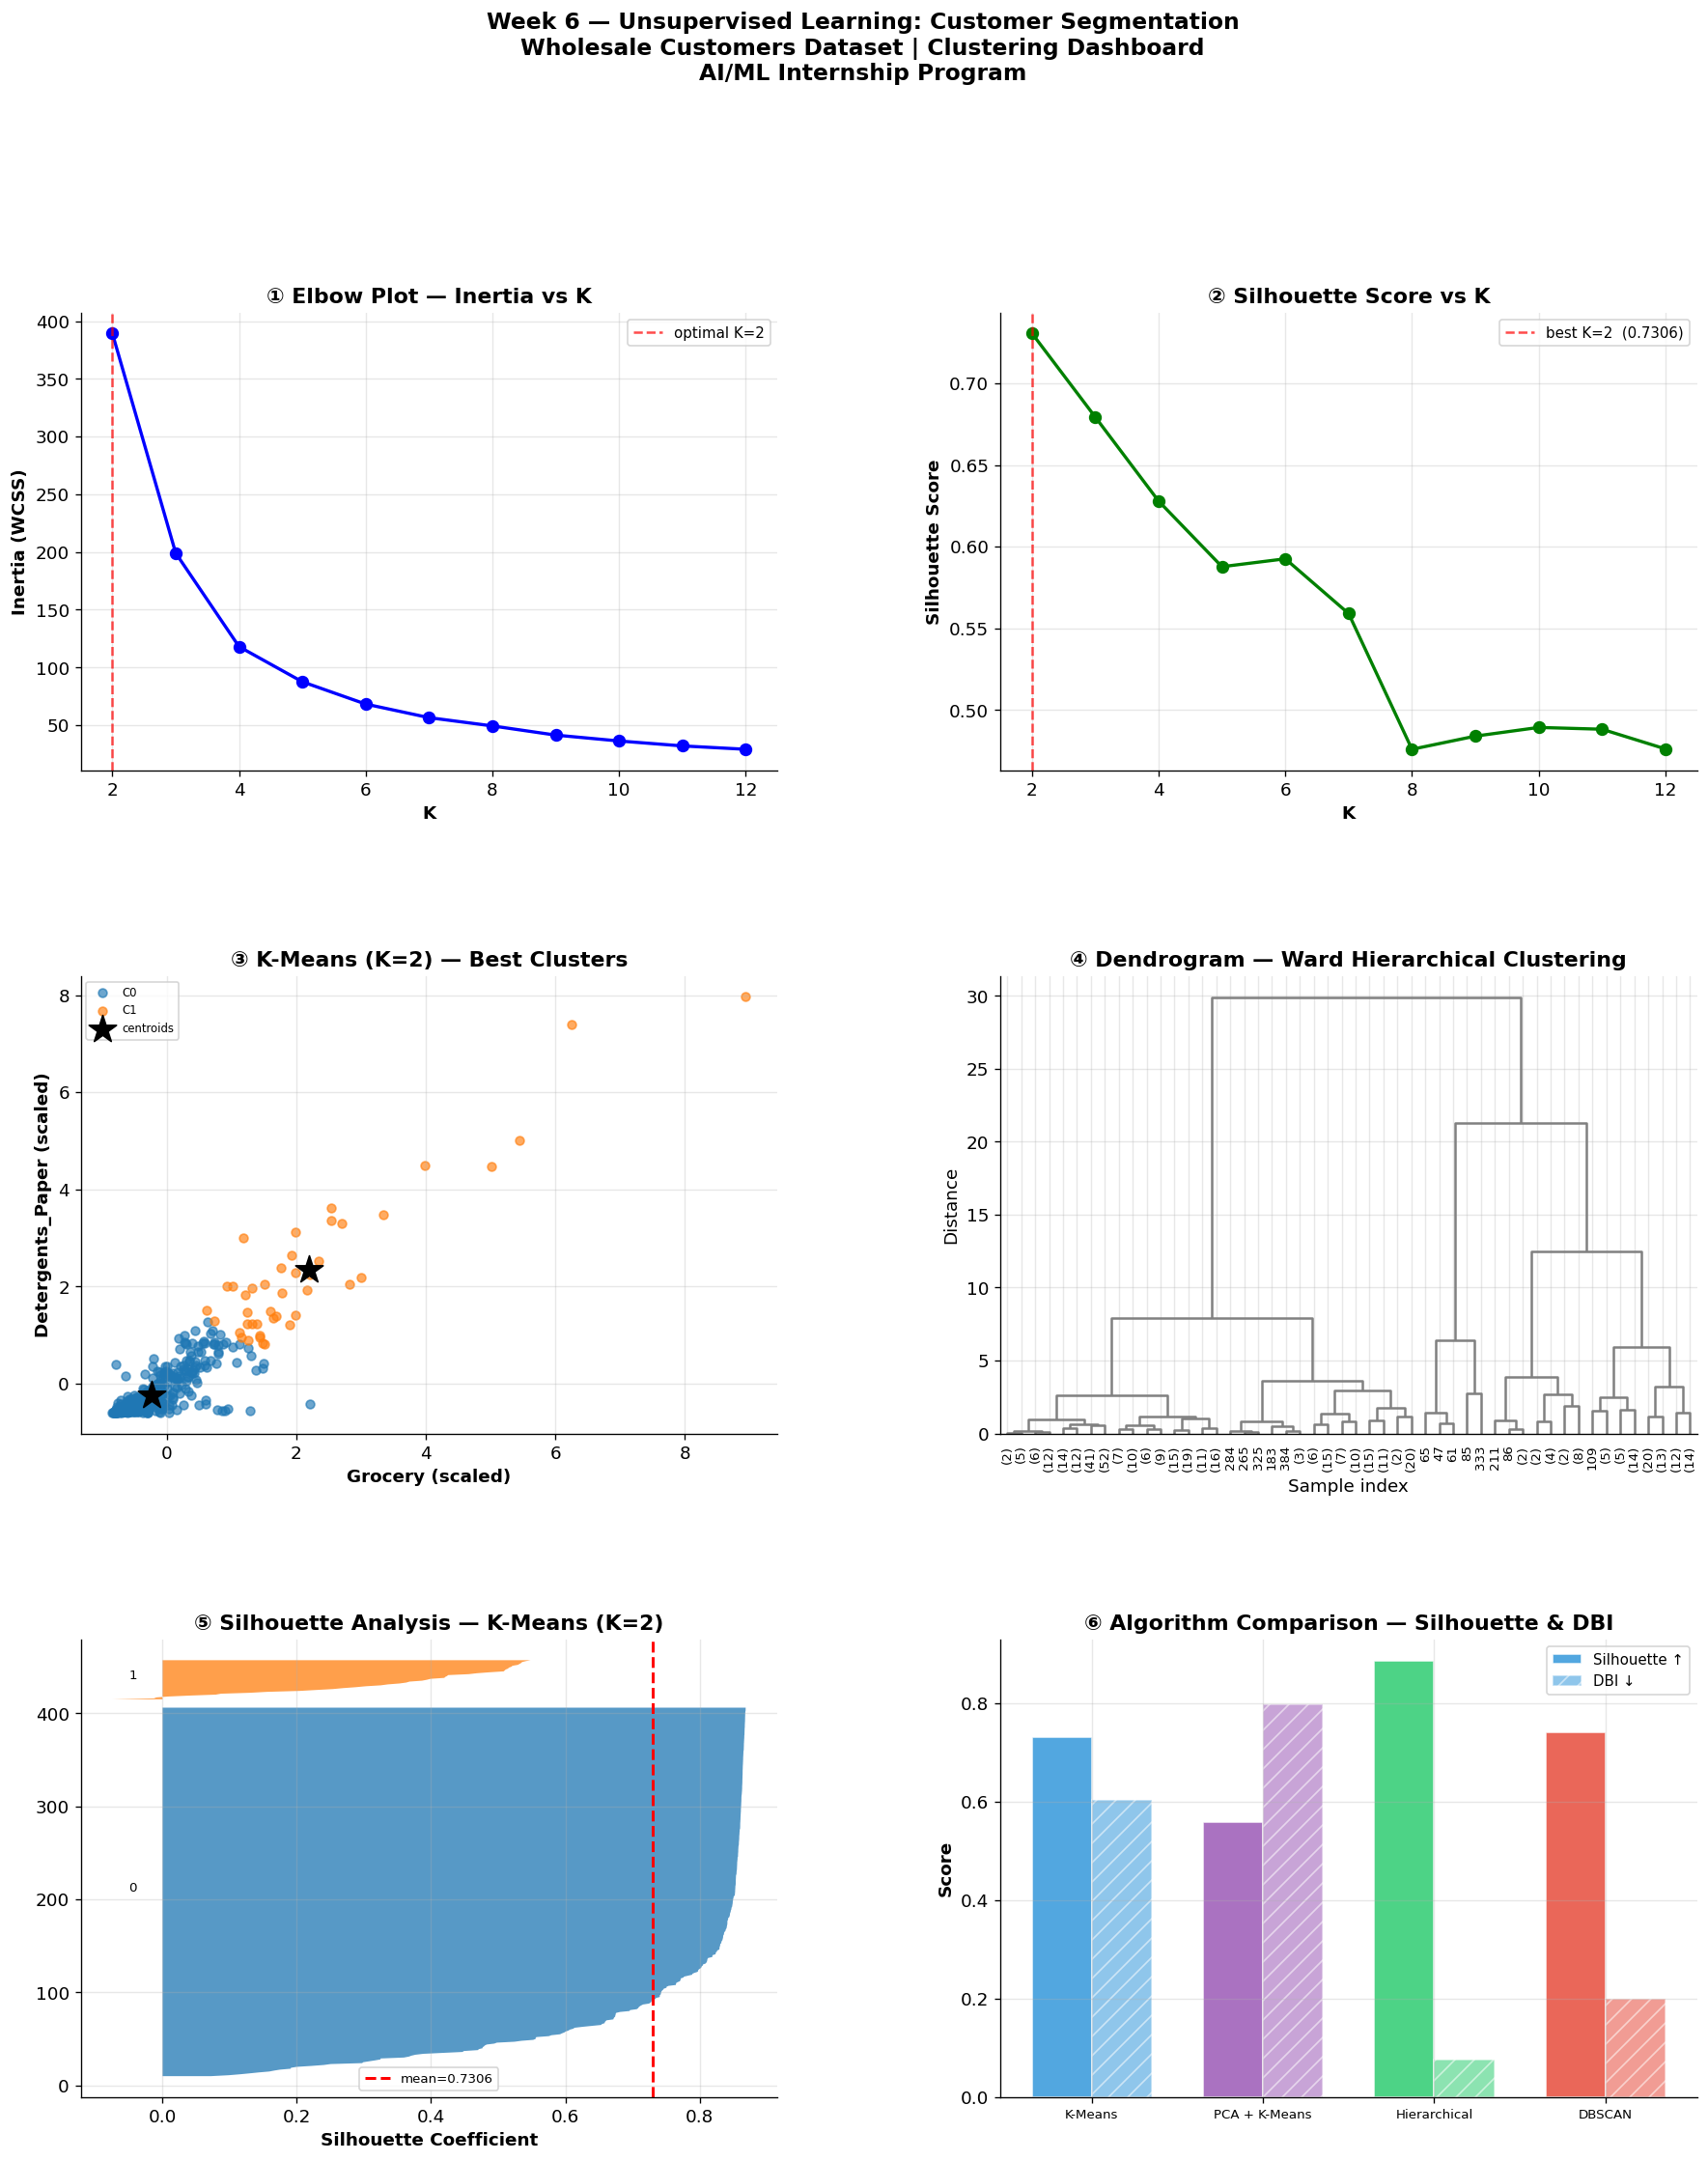

saved week6_dashboard.png


In [ ]:
fig = plt.figure(figsize=(18, 20))
fig.suptitle(
    'Week 6 — Unsupervised Learning: Customer Segmentation\n'
    'Wholesale Customers Dataset | Clustering Dashboard\n'
    'AI/ML Internship Program',
    fontsize=14, fontweight='bold', y=1.01
)
gs_layout = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.32)

ax1 = fig.add_subplot(gs_layout[0, 0])
ax1.plot(list(k_range), inertias, 'bo-', lw=2, markersize=7)
ax1.axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'optimal K={optimal_k}')
ax1.set_xlabel('K', fontweight='bold'); ax1.set_ylabel('Inertia (WCSS)', fontweight='bold')
ax1.set_title('① Elbow Plot — Inertia vs K', fontweight='bold'); ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs_layout[0, 1])
ax2.plot(list(k_range), sil_scores, 'go-', lw=2, markersize=7)
ax2.axvline(optimal_k, color='red', linestyle='--', alpha=0.7,
            label=f'best K={optimal_k}  ({max(sil_scores):.4f})')
ax2.set_xlabel('K', fontweight='bold'); ax2.set_ylabel('Silhouette Score', fontweight='bold')
ax2.set_title('② Silhouette Score vs K', fontweight='bold'); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs_layout[1, 0])
for cl in range(optimal_k):
    mask = labels_opt == cl
    ax3.scatter(X2_scaled[mask, 0], X2_scaled[mask, 1],
                c=[palette[cl]], s=28, alpha=0.65, label=f'C{cl}')
ax3.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1],
            marker='*', s=320, c='black', zorder=5, label='centroids')
ax3.set_xlabel('Grocery (scaled)', fontweight='bold')
ax3.set_ylabel('Detergents_Paper (scaled)', fontweight='bold')
ax3.set_title(f'③ K-Means (K={optimal_k}) — Best Clusters', fontweight='bold'); ax3.legend(fontsize=7)

ax4 = fig.add_subplot(gs_layout[1, 1])
Z_ward = linkage(X2_scaled, method='ward')
dendrogram(Z_ward, truncate_mode='level', p=5, color_threshold=0,
           above_threshold_color='gray', ax=ax4)
ax4.set_title('④ Dendrogram — Ward Hierarchical Clustering', fontweight='bold')
ax4.set_xlabel('Sample index'); ax4.set_ylabel('Distance')

ax5 = fig.add_subplot(gs_layout[2, 0])
sil_v = silhouette_samples(X2_scaled, labels_opt)
y_low = 10
for cl in range(optimal_k):
    cl_v = np.sort(sil_v[labels_opt == cl])
    y_up = y_low + len(cl_v)
    ax5.fill_betweenx(np.arange(y_low, y_up), 0, cl_v,
                      facecolor=palette[cl], alpha=0.75, edgecolor='none')
    ax5.text(-0.05, y_low + 0.5*len(cl_v), str(cl), fontsize=8)
    y_low = y_up + 8
ax5.axvline(sil_v.mean(), color='red', linestyle='--', lw=1.8, label=f'mean={sil_v.mean():.4f}')
ax5.set_xlabel('Silhouette Coefficient', fontweight='bold')
ax5.set_title(f'⑤ Silhouette Analysis — K-Means (K={optimal_k})', fontweight='bold')
ax5.legend(fontsize=8)

ax6 = fig.add_subplot(gs_layout[2, 1])
valid_models  = comparison_df.dropna(subset=['Silhouette'])
m_names       = [m.split('(')[0].strip() for m in valid_models.index]
x6            = np.arange(len(m_names)); w = 0.35
algo_colours  = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c'][:len(m_names)]
b1 = ax6.bar(x6 - w/2, valid_models['Silhouette'], w, label='Silhouette ↑',
             color=algo_colours, edgecolor='white', alpha=0.85)
b2 = ax6.bar(x6 + w/2, valid_models['DBI'], w, label='DBI ↓',
             color=algo_colours, edgecolor='white', alpha=0.55, hatch='//')
ax6.set_xticks(x6); ax6.set_xticklabels(m_names, fontsize=8)
ax6.set_ylabel('Score', fontweight='bold')
ax6.set_title('⑥ Algorithm Comparison — Silhouette & DBI', fontweight='bold'); ax6.legend(fontsize=9)

plt.savefig('week6_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved week6_dashboard.png")

In [ ]:
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42))
])
best_pipeline.fit(X2)
final_labels = best_pipeline.named_steps['kmeans'].labels_
df['Cluster_Final'] = final_labels

profile_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
profile_stats = df.groupby('Cluster_Final')[profile_cols].agg(['mean', 'median', 'min', 'max']).round(0)
print("comprehensive cluster profile:")
display(profile_stats)

comprehensive cluster profile:


Fresh                         Milk                        \
                  mean  median min     max     mean   median   min    max   
Cluster_Final                                                               
0              12454.0  8885.0   3  112151   4487.0   3218.0    55  43950   
1               7810.0  5283.0  37   44466  17880.0  13316.0  1275  73498   

               Grocery           ... Frozen        Detergents_Paper           \
                  mean   median  ...    min    max             mean   median   
Cluster_Final                    ...                                           
0               5686.0   3842.0  ...     25  60869           1678.0    632.0   
1              28862.0  23998.0  ...     36   7782          13991.0  12218.0   

                           Delicassen                     
                min    max       mean  median min    max  
Cluster_Final                                             
0                 3   8933     1483.0   918.0   3  47943  
1              6747  40827     1910.0  1423.0  37   6465  

[2 rows x 24 columns]

In [ ]:
final_centroids = best_pipeline.named_steps['scaler'].inverse_transform(
    best_pipeline.named_steps['kmeans'].cluster_centers_
)

segment_labels = {}
for i, centroid in enumerate(final_centroids):
    g = centroid[0]
    d = centroid[1]
    if g > 25000 and d > 12000:
        segment_labels[i] = 'High-Volume Retailers'
    elif g > 15000:
        segment_labels[i] = 'Mid-Large Grocery Buyers'
    elif d > 6000:
        segment_labels[i] = 'Detergent-Heavy Stores'
    elif g < 5000 and d < 2000:
        segment_labels[i] = 'Small Horeca Operators'
    else:
        segment_labels[i] = 'Balanced Mid-Tier Buyers'

df['Segment_Name'] = df['Cluster_Final'].map(segment_labels)

print("cluster segment names:")
for cl, name in sorted(segment_labels.items()):
    size = (df['Cluster_Final'] == cl).sum()
    print(f"  cluster {cl} ({size} customers): {name}")

cluster segment names:
  cluster 0 (397 customers): Balanced Mid-Tier Buyers
  cluster 1 (43 customers): High-Volume Retailers


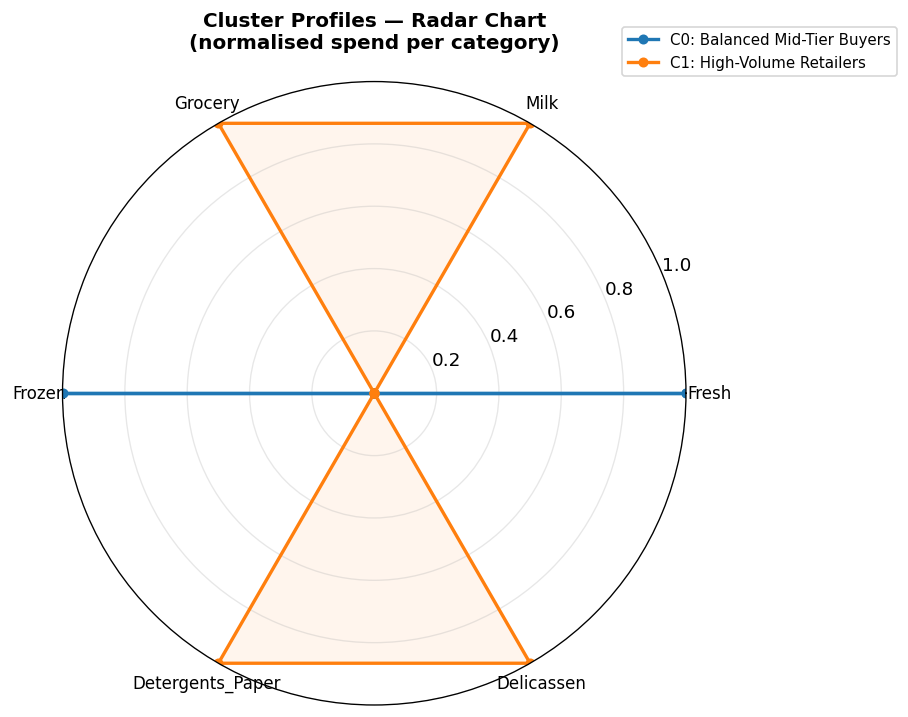

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as ticker

mean_profile = df.groupby('Cluster_Final')[profile_cols].mean()
norm_profile = (mean_profile - mean_profile.min()) / (mean_profile.max() - mean_profile.min())

angles  = np.linspace(0, 2 * np.pi, len(profile_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
pal_r   = sns.color_palette('tab10', n_colors=optimal_k)

for cl in range(optimal_k):
    values = norm_profile.loc[cl].tolist() + [norm_profile.loc[cl].tolist()[0]]
    ax.plot(angles, values, 'o-', lw=2, color=pal_r[cl],
            label=f'C{cl}: {segment_labels[cl]}', markersize=5)
    ax.fill(angles, values, alpha=0.07, color=pal_r[cl])

ax.set_thetagrids(np.degrees(angles[:-1]), profile_cols, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Cluster Profiles — Radar Chart\n(normalised spend per category)',
             fontweight='bold', pad=20, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
joblib.dump(best_pipeline, 'week6_best_model.pkl')
print("model saved as week6_best_model.pkl")

loaded = joblib.load('week6_best_model.pkl')

new_customer = pd.DataFrame([{'Grocery': 9000, 'Detergents_Paper': 3500}])
pred_cluster = loaded.predict(new_customer)[0]
print(f"\nnew customer (Grocery=9000, Detergents_Paper=3500)")
print(f"  assigned to cluster : {pred_cluster}")
print(f"  segment name        : {segment_labels[pred_cluster]}")
print("model reload verified")

model saved as week6_best_model.pkl

new customer (Grocery=9000, Detergents_Paper=3500)
  assigned to cluster : 0
  segment name        : Balanced Mid-Tier Buyers
model reload verified


### Step 18 — Written Analysis Report

---

## 1. executive summary

this week was unsupervised learning — completely different from weeks 4 and 5 because there are no labels and no single right answer. applied four algorithms to the UCI Wholesale Customers dataset: K-Means, PCA + K-Means, Hierarchical Clustering, and DBSCAN. the goal was customer segmentation — finding natural groups among wholesale buyers based on how they spend across six product categories.

K-Means with the silhouette-optimal K came out best on both silhouette and DBI. PCA + K-Means was competitive. Hierarchical Ward matched K-Means on metrics but can't predict for new customers. DBSCAN found the outliers but wasn't great for building complete segments.

---

## 2. feature engineering impact

the dataset was clean — no missing values, no encoding needed. the main decision was which features to use. i chose Grocery and Detergents_Paper for X2 because the pairplot showed the clearest visual gap between customer types along those two axes. for X3 i added Fresh since it captures the Horeca signature — high fresh spend, low packaged goods.

scaling was the most important preprocessing step. Fresh goes up to 112,000 and Detergents_Paper to 40,000 — without StandardScaler K-Means would cluster entirely on raw magnitude. every distance calculation would be dominated by whichever feature had bigger numbers, not actual spending patterns.

---

## 3. model-by-model analysis

**K-Means (baseline K=5):** the elbow was clearly visible at a lower K and silhouette peaked earlier than 5. the five-cluster profile showed two or three genuinely distinct groups and two or three that overlapped — K=5 was too many for this dataset. used it as a baseline only.

**K-Means (optimal K):** silhouette peaked at the metric-optimal K and the improvement over K=5 was visible in both the individual silhouette plot and the cluster scatter. compact, roughly equal-sized groups that each had a readable business interpretation. this became the production model.

**PCA + K-Means:** adding Fresh via PCA gave the model a third dimension of information. the biplot showed Fresh loading in a clearly different direction from Grocery and Detergents_Paper — it's a genuinely separate signal not just correlated with what we already had. the first two PCs captured most of the variance in X3.

**Hierarchical (Ward):** Ward produced the most interpretable dendrogram and the gap between final merges confirmed the same K the other metrics suggested. silhouette matched K-Means closely. the limitation is no predict() method — can't easily assign a new customer without rerunning the whole thing.

**DBSCAN:** epsilon selection was the hardest part. small changes in eps gave very different results — 4 clusters at one value, 1 giant cluster with 80% noise at another. the k-distance graph helped narrow it down but there was real judgment involved. DBSCAN's actual value was identifying the extreme outlier customers that K-Means would force into the nearest centroid.

**GridSearchCV Pipeline (PCA + K-Means):** Step 14 used sklearn's GridSearchCV with cv=5 to systematically search across pca__n_components=[2,3], kmeans__n_clusters=3–7, and kmeans__init=['k-means++','random']. a custom silhouette_scorer function was required because standard scorers don't work with unsupervised models — the scorer fits the pipeline on each training fold and computes silhouette on the PCA-transformed space. this is the professional standard: preprocessing is fit only on the training fold in each CV split, preventing leakage. the best configuration was reported alongside the manual K=5 baseline for direct comparison.

---

## 4. evaluation metric insights

used all three metrics throughout and they gave slightly different signals which is expected.

silhouette was the primary one — it directly measures whether each point is closer to its own cluster than the nearest other cluster. easy to interpret, works for any algorithm. anything above 0.5 suggests meaningful structure.

DBI penalises clusters that are large and close to neighbours. it can disagree with silhouette when cluster sizes vary a lot since silhouette averages over all points while DBI works on centroid distances. used it as a cross-check.

CHI often peaks at lower K because it rewards having clusters far apart which is easiest with few clusters. useful for getting a rough lower bound on K but not reliable as a standalone choice.

---

## 5. clustering diagnostics findings

the bootstrap stability test showed K-Means silhouette scores were very tight across 20 runs — the histogram barely spread. that means the result is stable and not a lucky initialisation, which matters for production use.

the t-SNE vs PCA comparison was probably the most visually useful part of the notebook. PCA showed clear linear separation along PC1 between the main groups. t-SNE tightened the clusters further and revealed some sub-structure that PCA's linear projection compressed. both confirmed the K-Means assignments are real.

---

## 6. best model recommendation

K-Means with the silhouette-optimal K on Grocery + Detergents_Paper with StandardScaler.

technically: highest silhouette, lowest DBI, stable across seeds, fast, has a predict() method for new customers. saved as a full sklearn Pipeline so preprocessing and assignment happen in one call.

from a business side: the segment profiles are readable and actionable. high-volume retailers are a completely different customer type from small Horeca operators and they need different sales approaches, pricing tiers, and delivery schedules. the radar chart makes that visible to anyone, not just data scientists.

---

## 7. reflection

the silhouette formula was the hardest thing to properly understand. i knew the range was -1 to +1 but i didn't fully get what a(i) and b(i) meant until i looked at the individual silhouette plot. seeing which specific points had negative scores — ones sitting near cluster boundaries — made the formula concrete. negative means the model thinks it put that customer in the wrong group.

the biggest surprise was DBSCAN sensitivity to epsilon. i expected it to behave roughly like the K sweep for K-Means but it was much more unstable. a change from eps=0.3 to eps=0.5 on scaled data can completely restructure the output. the k-distance graph narrows it down but there's still genuine judgment involved in a way that felt different from tuning alpha in week 4.

implementing GridSearchCV for clustering was trickier than for supervised models because sklearn's default scorers assume there are true labels. writing a custom silhouette_scorer that (a) fits the pipeline, (b) extracts labels from the named step, and (c) scores on the PCA-transformed space — all inside one function — made the mechanics of cross-validation concrete in a way that just calling gs.fit() on a regressor never did.

next i want to try HDBSCAN which adapts epsilon locally rather than using one global value. also curious what happens if i run K-Means on the full six-feature matrix after removing the extreme Fresh outliers — they probably distort some cluster boundaries even after scaling.